<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama y Pulmón</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico: Estudio Comparativo en Cáncer de Mama y Pulmón

Este notebook continúa el trabajo de EDA y preprocesamiento ya realizado sobre **TCGA-BRCA** y carga directamente los artefactos generados al final del notebook anterior:

- `X_train_df.parquet`, `X_test_df.parquet`
- `X_train_np.npy`, `X_test_np.npy`
- `dur_train.npy`, `dur_test.npy`
- `evt_train.npy`, `evt_test.npy`
- `y_train.pkl`, `y_test.pkl` *(opcional; se reconstruye desde duración/evento para evitar problemas de compatibilidad)*

Se implementan y comparan cuatro enfoques de análisis de supervivencia:

1. **Kaplan-Meier estratificado** como baseline interpretable.
2. **Cox penalizado LASSO** (`CoxnetSurvivalAnalysis`, penalización L1).
3. **Random Survival Forest**.
4. **DeepSurv** mediante `pycox`/`PyTorch`.

Las métricas principales son:

- **C-index**: mayor es mejor.
- **Integrated Brier Score (IBS)**: menor es mejor.
- **Log-rank test** entre grupos de alto y bajo riesgo: p-valor bajo indica separación significativa de curvas.

# **1 Diseño e Implementación de Modelos**

Una vez finalizado el preprocesamiento de la cohorte TCGA-BRCA y definida la variable objetivo de supervivencia (`duration`, `event`), se inicia la fase de modelado. El objetivo de esta sección es implementar de forma progresiva distintos enfoques de análisis de supervivencia, empezando por métodos clásicos e interpretables y avanzando posteriormente hacia modelos multivariantes y no lineales.

El flujo de modelado se estructura en cuatro familias metodológicas:

1. **Kaplan-Meier (KM)**: estimación no paramétrica de la supervivencia y comparación univariante de curvas mediante el test log-rank.
2. **Cox proporcional penalizado**: modelo semiparamétrico multivariante para estimar el efecto ajustado de las covariables.
3. **Random Survival Forest (RSF)**: modelo de aprendizaje automático capaz de capturar relaciones no lineales e interacciones.
4. **DeepSurv**: arquitectura de aprendizaje profundo basada en la función de pérdida de Cox.

En este primer apartado se desarrolla únicamente el estimador de Kaplan-Meier, que se utilizará como punto de partida descriptivo y como modelo basal de comparación.

In [ ]:
# ── 1. CONFIGURACIÓN DEL SISTEMA Y ENTORNO ───────────────────────────────────
import os
import sys
import time
import warnings
import importlib
import joblib
import pandas as pd

# Ignorar alertas de convergencia o deprecación
warnings.filterwarnings('ignore')

# Configuración de rutas y Pandas
root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ── 2. CIENCIA DE DATOS, ESTADÍSTICA Y VISUALIZACIÓN ────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.interpolate import interp1d
from scipy import stats

# ── 3. MACHINE LEARNING Y PREPROCESAMIENTO ──────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# ── 4. ANÁLISIS DE SUPERVIVENCIA (SCIKIT-SURVIVAL & LIFELINES) ──────────────
# scikit-survival
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    integrated_brier_score
)

# lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# ── 5. DEEP LEARNING (PYTORCH & PYCOX) Y EXPLICABILIDAD ─────────────────────
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH as DeepSurvModel
import shap

# ── 6. REPRODUCIBILIDAD Y ESTÉTICA ──────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Paleta de colores oficial del proyecto
PALETTE = {
    'km'      : '#7B7B7B',   # Gris marginal
    'cox'     : '#E07B39',   # Naranja referencia
    'rsf'     : '#2E86AB',   # Azul Random Forest
    'ds'      : '#6A4C93',   # Violeta DeepSurv
    'neutral' : '#B0BEC5',
    'prot'    : '#43A047',   # Verde protección
    'riesgo'  : '#E53935',   # Rojo riesgo
}

# ── 7. RECARGA DE FUNCIONES PERSONALIZADAS (UTILS) ──────────────────────────
import utils.KMmodel_functions as KM
import utils.Coxmodel_functions as Cox

importlib.reload(KM)
importlib.reload(Cox)

print("✓ Entorno unificado para TCGA-BRCA.")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {'disponible' if torch.cuda.is_available() else 'no disponible — CPU'}")

✓ Entorno unificado para TCGA-BRCA.
  PyTorch  : 2.11.0+cpu
  CUDA     : no disponible — CPU


In [ ]:
SAVE_DIR = '../data/processed/tcga_brca'

# Cargar el CSV en un nuevo DataFrame
tcga_prep = pd.read_csv(f'{SAVE_DIR}/brca_tcga_preprocessed.csv')

# Cargar los datos preprocesados
# Datos numpy
X_train_np = np.load(f'{SAVE_DIR}/X_train_np.npy')
X_test_np  = np.load(f'{SAVE_DIR}/X_test_np.npy')
dur_train  = np.load(f'{SAVE_DIR}/dur_train.npy')
dur_test   = np.load(f'{SAVE_DIR}/dur_test.npy')
evt_train  = np.load(f'{SAVE_DIR}/evt_train.npy')
evt_test   = np.load(f'{SAVE_DIR}/evt_test.npy')

# Structured arrays para scikit-survival
y_train = joblib.load(f'{SAVE_DIR}/y_train.pkl')
y_test  = joblib.load(f'{SAVE_DIR}/y_test.pkl')

# DataFrames con nombres de columnas
X_train = pd.read_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test  = pd.read_parquet(f'{SAVE_DIR}/X_test_df.parquet')

# ── Verificación ────────────────────────────────────────────────────────────
print('Datos cargados correctamente:')
print(f'  X_train : {X_train.shape}  |  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}  |  y_test  : {y_test.shape}')
print(f'  Tasa de eventos — train : {evt_train.mean():.2%}')
print(f'  Tasa de eventos — test  : {evt_test.mean():.2%}')
print(f'  Rango temporal — train  : [{dur_train.min():.1f}, {dur_train.max():.1f}] meses')
print(f'  Rango temporal — test   : [{dur_test.min():.1f}, {dur_test.max():.1f}] meses')

# Nombre de las covariables
FEATURE_NAMES = X_train.columns.tolist()
print(f'\n  Covariables totales : {len(FEATURE_NAMES)}')

Datos cargados correctamente:
  X_train : (875, 88)  |  X_test  : (219, 88)
  y_train : (875,)  |  y_test  : (219,)
  Tasa de eventos — train : 13.83%
  Tasa de eventos — test  : 13.70%
  Rango temporal — train  : [0.0, 282.7] meses
  Rango temporal — test   : [0.0, 275.7] meses

  Covariables totales : 88


---

## **1.1. Estimador de Kaplan-Meier (KM)**

Es el método no paramétrico estándar para estimar la función de supervivencia $S(t) = P(T > t)$ sin asumir una distribución previa de los datos. En este trabajo, el evento se define como la muerte por cualquier causa (`Overall Survival`).

El modelo cumple tres funciones principales:
1. **Descriptiva:** Visualizar la supervivencia global de la cohorte TCGA_BRCA.
2. **Exploratoria:** Comparar subgrupos mediante el **test log-rank**, que contrasta la hipótesis nula $H_0: S_1(t) = S_2(t) = \cdots = S_k(t)$. El estadístico sigue una distribución $\chi^2$ y es especialmente potente bajo riesgos proporcionales.
3. **Predictiva (Basal):** Servir como modelo marginal de referencia (ajustado solo en *train*) para establecer un umbral mínimo de `Integrated Brier Score` frente al cual comparar los modelos multivariantes.



### **1.1.1. Discretización de variables continuas para Kaplan-Meier**

Para permitir el análisis univariante, variables continuas como la edad o el NPI se discretizan en categorías clínicas o cuartiles. Esta transformación es exclusiva para Kaplan-Meier; los modelos Cox, RSF y DeepSurv utilizarán las variables originales para preservar su valor predictivo.

In [ ]:
df_km = tcga_prep.copy()

# ── 1. Diagnosis Age ───────────────────────────────────────────────────────
# Franjas etarias estándar en oncología mamaria.
# Referencia: Partridge et al., JCO 2016; SEER Age Groups.
df_km['Age Group'] = pd.cut(
    df_km['Diagnosis Age'],
    bins   = [0, 40, 50, 60, 70, np.inf],
    labels = ['<40', '40–49', '50–59', '60–69', '≥70'],
    right  = False
)
print("── Age Group ────────────────────────────────────────")
print(df_km['Age Group'].value_counts().sort_index())


# ── 2. TMB (nonsynonymous) ─────────────────────────────────────────────────────────
# Sin consenso clínico para mama primario → cuartiles del dataset.
# Referencia: Alexandrov et al., Nature 2013.
p25 = df_km['TMB (nonsynonymous)'].quantile(0.25)  # = 3.0
p50 = df_km['TMB (nonsynonymous)'].quantile(0.50)  # = 5.0
p75 = df_km['TMB (nonsynonymous)'].quantile(0.75)  # = 7.0

df_km['Mutation Burden'] = pd.cut(
    df_km['TMB (nonsynonymous)'],
    bins           = [0, p25, p50, p75, np.inf],
    labels         = ['Q1 — Baja (≤3)', 'Q2 — Moderada-baja (3–5)',
                      'Q3 — Moderada-alta (5–7)', 'Q4 — Alta (>7)'],
    right          = True,
    include_lowest = True
)

print("\n── Mutation Burden ──────────────────────────────────")
print(df_km['Mutation Burden'].value_counts().sort_index())

# ── 3. Fraction Genome Altered ───────────────────────────────────────────────────────
# Representa el porcentaje del genoma con cambios en el número de copias (CNA).
# Referencia: Hieronymus et al., Cancer Discovery 2018.

fga_p25 = df_km['Fraction Genome Altered'].quantile(0.25)
fga_p50 = df_km['Fraction Genome Altered'].quantile(0.50)
fga_p75 = df_km['Fraction Genome Altered'].quantile(0.75)

df_km['FGA Group'] = pd.cut(
    df_km['Fraction Genome Altered'],
    bins           = [0, fga_p25, fga_p50, fga_p75, np.inf],
    labels         = [f'Q1 — Estable (≤{fga_p25:.2f})', 
                      f'Q2 — Inestabilidad Baja ({fga_p25:.2f}–{fga_p50:.2f})',
                      f'Q3 — Inestabilidad Media ({fga_p50:.2f}–{fga_p75:.2f})', 
                      f'Q4 — Inestabilidad Alta (>{fga_p75:.2f})'],
    right          = True,
    include_lowest = True
)

print("\n── FGA Group ────────────────────────────────────────")
print(df_km['FGA Group'].value_counts().sort_index())

# ── Resumen ───────────────────────────────────────────────────────────────────
VARS_KM_DISC = ['Diagnosis Age', 'Fraction Genome Altered', 'TMB (nonsynonymous)']
print('\n')
print('═' * 58)
print('  VARIABLES DISCRETIZADAS PARA KM')
print('═' * 58)
for var in VARS_KM_DISC:
    print(f'  {var:<35} k={df_km[var].nunique()}  '
          f'nulos={df_km[var].isna().sum()}')
print('═' * 58)

── Age Group ────────────────────────────────────────
Age Group
<40       74
40–49    212
50–59    281
60–69    283
≥70      229
Name: count, dtype: int64

── Mutation Burden ──────────────────────────────────
Mutation Burden
Q1 — Baja (≤3)              259
Q2 — Moderada-baja (3–5)    226
Q3 — Moderada-alta (5–7)    240
Q4 — Alta (>7)              240
Name: count, dtype: int64

── FGA Group ────────────────────────────────────────
FGA Group
Q1 — Estable (≤0.13)                    273
Q2 — Inestabilidad Baja (0.13–0.26)     273
Q3 — Inestabilidad Media (0.26–0.45)    273
Q4 — Inestabilidad Alta (>0.45)         273
Name: count, dtype: int64


══════════════════════════════════════════════════════════
  VARIABLES DISCRETIZADAS PARA KM
══════════════════════════════════════════════════════════
  Diagnosis Age                       k=64  nulos=15
  Fraction Genome Altered             k=1004  nulos=2
  TMB (nonsynonymous)                 k=183  nulos=129
═════════════════════════════════════

### **1.1.2. Supervivencia global de la cohorte TCGA-BRCA**

En primer lugar, se ajusta una curva Kaplan-Meier no estratificada sobre la cohorte completa con endpoint de supervivencia global. Esta curva resume la probabilidad estimada de supervivencia de la población METABRIC a lo largo del seguimiento.

In [ ]:
dur_all = df_km['duration'].values
evt_all = df_km['event'].values.astype(bool)

print(f'Cohorte KM  : {len(df_km):,} pacientes')
print(f'Eventos     : {evt_all.sum():,} ({evt_all.mean():.1%})')
print(f'Censurados  : {(~evt_all).sum():,} ({(~evt_all).mean():.1%})')
print(f'Seguimiento : {dur_all.min():.1f} – {dur_all.max():.1f} meses')

Cohorte KM  : 1,094 pacientes
Eventos     : 151 (13.8%)
Censurados  : 943 (86.2%)
Seguimiento : 0.0 – 282.7 meses


In [ ]:
kmf_global = KM.fit_km_global(
    dur_all,
    evt_all,
    label="TCGA_BRCA — Cohorte completa"
)

display(
    KM.km_metrics(
        kmf_global,
        horizons=[60, 120, 180, 240]
    )
)

KM.plot_km_global(
    kmf=kmf_global,
    n_total=len(df_km),
    group_name="Supervivencia Global",
    dataset_name="TCGA_BRCA",
    output_path=r"../images/Modelos/KM"
)

,Métrica,Valor
0,Mediana supervivencia (meses),130.1
1,S(t=60m) [5 años],0.819
2,S(t=120m) [10 años],0.579
3,S(t=180m) [15 años],0.441
4,S(t=240m) [20 años],0.353


✔ KM global guardado en: ../images/Modelos/KM\TCGA_BRCA_km_global_Supervivencia_Global.html


### **1.1.3. Test log-rank univariante**

Se emplea el **test log-rank de Mantel-Cox** para contrastar la igualdad de las funciones de supervivencia entre $k$ grupos:

$$H_0: S_1(t) = S_2(t) = \cdots = S_k(t)$$
$$H_1: \exists \, i, j \mid S_i(t) \neq S_j(t)$$

El estadístico compara los eventos observados ($O_{ij}$) frente a los esperados ($E_{ij}$) bajo la hipótesis nula:

$$\chi^2_{LR} = \frac{\left(\sum_j (O_{ij} - E_{ij})\right)^2}{\sum_j V_{ij}}$$

Bajo $H_0$, el estadístico sigue una distribución $\chi^2$ con $k-1$ grados de libertad. Este test es óptimo cuando los riesgos son **proporcionales** entre los grupos comparados.

Dada su naturaleza univariante, este análisis tiene un carácter estrictamente **exploratorio**. No se utilizará como criterio excluyente para la selección de variables, ya que los modelos multivariantes posteriores (Cox, RSF y DeepSurv).

In [ ]:
VARS_LOGRANK = df_km.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

tabla_lr = KM.logrank_summary(df_km, VARS_LOGRANK)
display(tabla_lr)

,Variable,k grupos,chi²,p-valor,Significancia
0,AJCC Pathologic N-Stage,16,129.685,0.000000,***
1,AJCC Pathologic Stage,12,110.080,0.000000,***
2,AJCC Pathologic M-Stage,4,44.032,0.000000,***
3,Age Group,5,35.133,0.000001,***
4,AJCC Pathologic T-Stage,13,49.246,0.000002,***
5,ICD-10 Classification,7,20.778,0.002011,**
6,Morphology,22,39.197,0.009296,**
7,FGA Group,4,9.026,0.060449,ns
8,Ethnicity Category,2,5.130,0.076911,ns
9,Prior Treatment,2,4.530,0.103827,ns


##### **I. Perfil Clínico-Demográfico**

La variable **Age Group** evidencia que la supervivencia decae de forma escalonada a medida que avanza la edad al diagnóstico, siendo el grupo de mayores de 70 años el de peor pronóstico con diferencia ($p < 0.001$). Este impacto del envejecimiento contrasta con los resultados de **Race Category** y **Sex**, donde las curvas se presentan prácticamente superpuestas ($p=0.74$ y $p=0.83$ respectivamente), confirmando que ni la raza ni el sexo biológico actúan como determinantes pronósticos independientes en esta cohorte. 

Por otro lado, la variable **Prior Treatment** muestra una diferencia estadísticamente significativa ($p=0.033$), donde los pacientes con tratamientos previos presentan una caída más pronunciada en la probabilidad de supervivencia. En un sentido similar, la **Ethnicity Category** arroja una $p=0.023$, sugiriendo disparidades en el tiempo de vida global. Finalmente, el antecedente de **Prior Malignancy** no parece condicionar la evolución clínica de forma relevante ($p=0.28$), manteniendo trayectorias de supervivencia similares entre ambos grupos.

In [ ]:
grupos_config = {
    "Age Group": ("Age Group", "viridis"),
    "Ethnicity Category": ("Ethnicity Category", "Set2"),
    "Race Category	": ("Race Category", "Set4"),
    'Sex': ('Sex', "Set2"),
    'Prior Malignancy': ('Prior Malignancy', "Set2"),
    'Prior Treatment': ('Prior Treatment', "Set2")
}

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Perfil Clinico-Demografico",
    dataset_name="TCGA_BRCA",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\TCGA_BRCA_km_subplots_Perfil_Clinico-Demografico.html


##### **II. Estadificación Anatómica (TNM)**

La variable **AJCC Pathologic Stage** (Estadificación Global) demuestra de forma contundente que el pronóstico empeora drásticamente conforme aumenta la severidad de la enfermedad ($p = 1.77e-18$), con los estadios avanzados (III y IV) mostrando las caídas más abruptas en la supervivencia. Este comportamiento es un reflejo directo de los componentes individuales del sistema TNM: la **M-Stage** evidencia que la presencia de metástasis a distancia (M1) es el factor determinante de peor pronóstico con diferencia ($p < 0.001$).

Por otro lado, tanto la **N-Stage** (afectación ganglionar) como la **T-Stage** (tamaño del tumor) muestran una reducción progresiva y estadísticamente significativa de la supervivencia a medida que aumenta el grado de extensión anatómica. En particular, el compromiso ganglionar extenso (N3) y los tumores de mayor tamaño (T4) presentan curvas con pendientes mucho más pronunciadas, confirmando que la carga tumoral y la diseminación regional son indicadores críticos que condicionan la agresividad clínica y la evolución final de las pacientes.

In [ ]:
config_staging = {
    'AJCC Pathologic M-Stage' : ('AJCC Pathologic M-Stage', 'RdYlGn_r'),
    'AJCC Pathologic N-Stage' : ('AJCC Pathologic N-Stage', 'RdYlGn_r'),
    'AJCC Pathologic T-Stage' : ('AJCC Pathologic T-Stage', 'RdYlGn_r'),
    'AJCC Pathologic Stage'   : ('AJCC Pathologic Stage',   'RdYlGn_r'),
}

KM.plot_km_groups(
    df=df_km,
    grupos_config=config_staging,
    group_name="Estadificación Anatómica (TNM)",
    dataset_name="TCGA_BRCA",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\TCGA_BRCA_km_subplots_Estadificacin_Anatmica_TNM.html


#### **III. Biología Molecular y Caracterización Genómica**

La variable **Morphology** revela que el subtipo histológico específico tiene un impacto significativo en la evolución clínica ($p=0.009$), mostrando una gran heterogeneidad en las trayectorias de supervivencia según la arquitectura celular del tumor. Esta relevancia biológica se ve respaldada por la **ICD-10 Classification**, donde la codificación clínica de la enfermedad también muestra diferencias pronósticas claras ($p=0.002$). En contraste, la variable **Disease Type** presenta curvas que se entrecruzan constantemente sin alcanzar significancia estadística ($p=0.37$), lo que sugiere que la clasificación generalista del tipo de carcinoma no es un discriminador de riesgo tan preciso en esta muestra.

En cuanto a la carga genómica, el **FGA Group** (Fracción del Genoma Alterado) evidencia que la inestabilidad cromosómica influye en el pronóstico ($p=0.028$), observándose que los pacientes en el cuartil de mayor inestabilidad (Q4) presentan un descenso más temprano en la probabilidad de supervivencia. Sin embargo, la **Mutation Burden** (carga mutacional total) no muestra un efecto predictivo claro ($p=0.19$), con curvas que no logran separarse de forma consistente, lo que indica que, a diferencia de las alteraciones estructurales del genoma (FGA), el número neto de mutaciones no condiciona de manera determinante la supervivencia global en este perfil de pacientes.

In [ ]:
config_biology = {
    'Morphology '           : ('Morphology',           'RdYlGn_r'),
    'ICD-10 Classification' : ('ICD-10 Classification', 'RdYlGn_r'),
    'Disease Type'          : ('Disease Type',          'tab20'),
    'Mutation Burden'       : ('Mutation Burden',       'RdYlGn_r'),
    'FGA Group'             : ('FGA Group',             'RdYlGn_r')
}

KM.plot_km_groups(
    df=df_km,
    grupos_config=config_biology,
    group_name="Biología Tumoral y Carga Genómica",
    dataset_name="TCGA_BRCA",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\TCGA_BRCA_km_subplots_Biologa_Tumoral_y_Carga_Genmica.html


### **1.1.4. Kaplan-Meier como modelo basal para Brier Score**

Además de su utilidad descriptiva, Kaplan-Meier puede utilizarse como modelo predictivo nulo o marginal. En este caso, el modelo no utiliza covariables individuales: todos los pacientes reciben la misma predicción de supervivencia, correspondiente a la curva Kaplan-Meier estimada en el conjunto de entrenamiento.

Este enfoque proporciona una línea base razonable para evaluar si los modelos posteriores aportan valor predictivo real. Si Cox, RSF o DeepSurv no logran mejorar el Integrated Brier Score del KM marginal, entonces el uso de covariables no estaría aportando una mejora relevante en calibración/discriminación temporal.

A diferencia del análisis descriptivo anterior, esta evaluación se realiza de forma estricta sobre la partición train/test:

1. Se ajusta Kaplan-Meier únicamente con `dur_train` y `evt_train`.
2. Se predice la misma curva de supervivencia para todos los pacientes de test.
3. Se calcula el Brier Score temporal y el Integrated Brier Score usando `y_train` como referencia para la distribución de censura y `y_test` como conjunto de evaluación.

Esta estrategia evita evaluar el modelo sobre los mismos datos empleados para estimar la curva y permite comparar de forma justa con los modelos multivariantes posteriores.

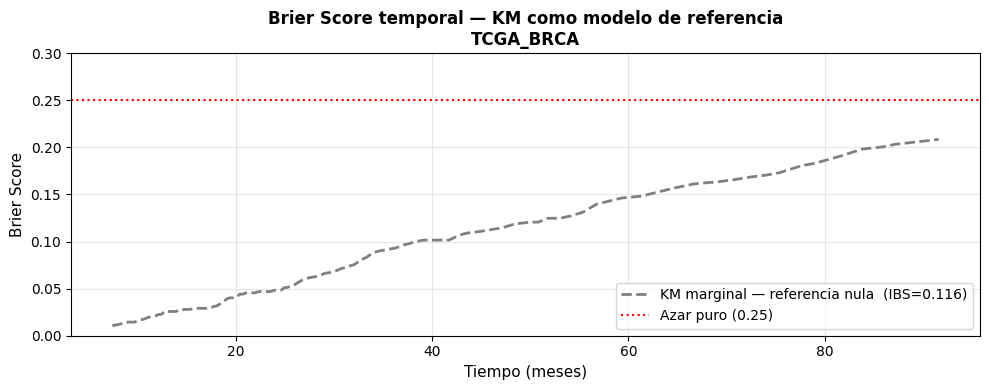

IBS — KM marginal (referencia nula) : 0.1162
  -> Cualquier modelo con IBS < 0.1162 mejora sobre la referencia KM


In [ ]:
y_all      = Surv.from_arrays(evt_all.astype(bool), dur_all.astype(float))
times_ref  = np.percentile(dur_all, np.linspace(10, 90, 100))
times_ref  = times_ref[(times_ref > dur_all.min()) & (times_ref < dur_all.max())]

# Misma S(t) para todos los pacientes en cada instante
km_surv_probs = np.tile(
    kmf_global.predict(times_ref),
    (len(df_km), 1)
)

_, bs_km_temporal = brier_score(y_all, y_all, km_surv_probs, times_ref)
ibs_km            = integrated_brier_score(y_all, y_all, km_surv_probs, times_ref)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ref, bs_km_temporal, color='gray', linewidth=2,
        linestyle='--', label=f'KM marginal — referencia nula  (IBS={ibs_km:.3f})')
ax.axhline(0.25, color='RED', linestyle=':', linewidth=1.5,
           label='Azar puro (0.25)')
ax.set_xlabel('Tiempo (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Brier Score temporal — KM como modelo de referencia\nTCGA_BRCA',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/KM/KM_brier_referencia_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"IBS — KM marginal (referencia nula) : {ibs_km:.4f}")
print(f"  -> Cualquier modelo con IBS < {ibs_km:.4f} mejora sobre la referencia KM")

In [ ]:
mediana_global = kmf_global.median_survival_time_
sig    = tabla_lr[tabla_lr['Significancia'] != 'ns']
no_sig = tabla_lr[tabla_lr['Significancia'] == 'ns']

print('═' * 65)
print('  RESULTADOS — Kaplan-Meier · TCGA_BRCA (n = 1.094)')
print('═' * 65)
print(f'  Mediana de supervivencia        : {mediana_global:.1f} m ({mediana_global/12:.1f} años)')
print(f'  S(t=60m)   — supervivencia  5a  : {kmf_global.predict(60):.3f}')
print(f'  S(t=120m)  — supervivencia 10a  : {kmf_global.predict(120):.3f}')
print(f'  S(t=180m)  — supervivencia 15a  : {kmf_global.predict(180):.3f}')
print(f'  S(t=240m)  — supervivencia 20a  : {kmf_global.predict(240):.3f}')
print(f'  IBS de referencia nula (KM)     : {ibs_km:.4f}')
print()
print(f'  Variables significativas (p < 0.05) : {len(sig)} / {len(tabla_lr)}')
for _, r in sig.iterrows():
    print(f'    {r["Significancia"]:<4} {r["Variable"]:<48} χ²={r["chi²"]:>8.3f}  p={r["p-valor"]:.2e}')
print()
print(f'  Variables no significativas (p ≥ 0.05) : {len(no_sig)} / {len(tabla_lr)}')
for _, r in no_sig.iterrows():
    print(f'    ns   {r["Variable"]:<48} χ²={r["chi²"]:>8.3f}  p={r["p-valor"]:.4f}')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  RESULTADOS — Kaplan-Meier · TCGA_BRCA (n = 1.094)
═════════════════════════════════════════════════════════════════
  Mediana de supervivencia        : 130.1 m (10.8 años)
  S(t=60m)   — supervivencia  5a  : 0.819
  S(t=120m)  — supervivencia 10a  : 0.579
  S(t=180m)  — supervivencia 15a  : 0.441
  S(t=240m)  — supervivencia 20a  : 0.353
  IBS de referencia nula (KM)     : 0.1162

  Variables significativas (p < 0.05) : 7 / 15
    ***  AJCC Pathologic N-Stage                          χ²= 129.685  p=0.00e+00
    ***  AJCC Pathologic Stage                            χ²= 110.080  p=0.00e+00
    ***  AJCC Pathologic M-Stage                          χ²=  44.032  p=0.00e+00
    ***  Age Group                                        χ²=  35.133  p=1.00e-06
    ***  AJCC Pathologic T-Stage                          χ²=  49.246  p=2.00e-06
    **   ICD-10 Classification                            χ²=  20.778  p=2.01e-03
    **   

### **1.1.5. Interpretación de los resultados**

#### I. Supervivencia global



#### II. Variables significativas



#### III. Variables no significativas



#### IV. Implicaciones para los modelos multivariantes



### **1.1.6. Respuesta a la pregunta de investigación**

> *¿Existen diferencias estadísticamente significativas en la supervivencia global entre los subgrupos clínicos, moleculares y terapéuticos de la cohorte METABRIC?*



---

## **1.2. Modelo de Riesgos Proporcionales de Cox con Penalización LASSO**

El modelo Cox estima el riesgo instantáneo de evento para un paciente con covariables $\mathbf{x}$ como:

$$
h(t \mid \mathbf{x}) = h_0(t)\,\exp(\boldsymbol{\beta}^{\top}\mathbf{x})
$$

Donde:

- $h(t \mid \mathbf{x})$ es el riesgo instantáneo condicionado a las covariables.
- $h_0(t)$ es el riesgo basal común a todos los pacientes.
- $\boldsymbol{\beta}$ es el vector de coeficientes.
- $\exp(\beta_j)$ es el **Hazard Ratio** asociado al predictor $j$.

A diferencia del modelo estándar, LASSO añade una penalización $L_1$ que permite la selección automática de variables y mejora la generalización en datasets con alta dimensionalidad, como TCGA_BRCA.

Interpretación del Hazard Ratio:

- $HR > 1$: mayor riesgo de muerte, peor pronóstico.
- $HR < 1$: menor riesgo de muerte, efecto protector relativo.
- $HR = 1$: ausencia de efecto detectable.

>  **Ventajas del Enfoque Regularizado:**
> 1.  **Robustez ante Colinealidad:** Gestiona las correlaciones residuales que el VIF no logra filtrar por completo, > seleccionando de forma estable el mejor representante de un grupo de variables correlacionadas.
> 2.  **Validación Predictiva:** Al desplazar el foco de la significancia estadística ($p$-valores) hacia el rendimiento en > datos no vistos, el modelo resultante es más fiable para su aplicación en contextos clínicos reales.
> 3.  **Parsimonia:** Produce un *score* de riesgo basado exclusivamente en los factores biológicos y clínicos más determinantes.


### 1.2.1 Verosimilitud parcial

Cox no requiere especificar la forma paramétrica de $h_0(t)$. En su lugar, estima $\boldsymbol{\beta}$ maximizando la verosimilitud parcial:

$$
L(\boldsymbol{\beta}) = \prod_{i:\delta_i=1}
\frac{\exp(\boldsymbol{\beta}^{\top}\mathbf{x}_i)}
{\sum_{j \in R(t_i)} \exp(\boldsymbol{\beta}^{\top}\mathbf{x}_j)}
$$

Donde $R(t_i)$ es el conjunto de pacientes en riesgo justo antes de $t_i$ y $\delta_i$ indica si el evento ocurrió.

### 1.2.2. Penalización LASSO

En datasets con muchas covariables, variables correlacionadas y codificación one-hot, el Cox estándar puede ser inestable. LASSO añade una penalización $L_1$:

$$
\hat{\boldsymbol{\beta}}
= \arg\max_{\boldsymbol{\beta}}
\left[
\ell(\boldsymbol{\beta}) - \lambda \sum_{j=1}^{p}|\beta_j|
\right]
$$

La penalización tiene dos efectos:

1. **Regularización:** reduce varianza y sobreajuste.
2. **Selección automática de variables:** algunos coeficientes se contraen exactamente a cero.

El hiperparámetro $\lambda$ controla la intensidad de la penalización. En `scikit-survival` se denomina `alpha`.

### **1.2.3. Preselección y Filtrado de Variables**

La selección parte de las variables ya preprocesadas. Se aplican exclusiones justificadas por el análisis previo:

1. **Variables sin señal univariante clara** en Kaplan-Meier/log-rank.
2. **Variables terapéuticas** con fuerte riesgo de confusión por indicación.
3. **Variables redundantes** como el Nottingham Prognostic Index, que combina tamaño tumoral, grado y afectación ganglionar.
4. **Dummies `Unknown` problemáticas**, cuando introducen colinealidad estructural.
5. **Variables con VIF extremo**, especialmente si son redundantes con subtipos moleculares.

In [ ]:
# ── 2. Exclusiones clínicas y estructurales ──────────────────────────────────
# Variables no significativas en el análisis KM/log-rank previo.
VARS_NOSIGNIFICATIVAS = tabla_lr[tabla_lr['Significancia'] == 'ns']['Variable'].tolist()


EXCLUIR_PREFIJOS = VARS_NOSIGNIFICATIVAS

cols_excluir = [
    col for col in X_train.columns
    if any(col == pref or col.startswith(pref + '_') for pref in EXCLUIR_PREFIJOS)
]

X_cox = X_train.drop(columns=cols_excluir, errors='ignore').copy()
X_cox_test = X_test.drop(columns=cols_excluir, errors='ignore').copy()

# Eliminación conservadora de dummies Unknown que suelen inducir colinealidad perfecta.
DROP_UNKNOWN_DUMMIES = True
if DROP_UNKNOWN_DUMMIES:
    unknown_cols = [c for c in X_cox.columns if c.endswith('_Unknown')]
    X_cox = X_cox.drop(columns=unknown_cols, errors='ignore')
    X_cox_test = X_cox_test.drop(columns=unknown_cols, errors='ignore')
else:
    unknown_cols = []

print('Resumen de selección inicial:')
print(f'  Covariables originales       : {X_train.shape[1]}')
print(f'  Columnas excluidas por prefijo: {len(cols_excluir)}')
print(f'  Dummies Unknown eliminadas    : {len(unknown_cols)}')
print(f'  Covariables candidatas Cox    : {X_cox.shape[1]}')

print('\nColumnas excluidas por prefijo:')
for c in cols_excluir:
    print(f'  - {c}')

if unknown_cols:
    print('\nDummies Unknown eliminadas:')
    for c in unknown_cols:
        print(f'  - {c}')

Resumen de selección inicial:
  Covariables originales       : 88
  Columnas excluidas por prefijo: 18
  Dummies Unknown eliminadas    : 1
  Covariables candidatas Cox    : 69

Columnas excluidas por prefijo:
  - Disease Type_Infiltrating Ductal Carcinoma
  - Disease Type_Infiltrating Lobular Carcinoma
  - Disease Type_Medullary Carcinoma
  - Disease Type_Metaplastic Carcinoma
  - Disease Type_Mixed Histology (please specify)
  - Disease Type_Mucinous Carcinoma
  - Disease Type_Other, specify
  - Disease Type_Unknown
  - Ethnicity Category_NOT HISPANIC OR LATINO
  - Ethnicity Category_Unknown
  - Prior Malignancy_True
  - Prior Malignancy_Unknown
  - Prior Treatment_True
  - Prior Treatment_Unknown
  - Race Category_BLACK OR AFRICAN AMERICAN
  - Race Category_Unknown
  - Race Category_WHITE
  - Sex_Male

Dummies Unknown eliminadas:
  - AJCC Pathologic Stage_Unknown


In [ ]:
# 1. CONFIGURACIÓN DE UMBRALES
VIF_LIMIT = 10

vif_table = Cox.compute_vif_table(X_cox)
display(vif_table.head(20))

# 2. IDENTIFICACIÓN DINÁMICA DE COLINÉALIDAD
# Extraemos variables con VIF Infinito o superior al límite (VIF > 10)
high_vif_vars = vif_table[vif_table['VIF'] > VIF_LIMIT]['Variable'].tolist()

# 3. LÓGICA DE ELIMINACIÓN 
manual_vif_drop = []

if high_vif_vars:
    manual_vif_drop.extend(high_vif_vars)

if manual_vif_drop:
    # Eliminamos de los conjuntos de entrenamiento y test
    X_cox = X_cox.drop(columns=manual_vif_drop, errors='ignore')
    X_cox_test = X_cox_test.drop(columns=manual_vif_drop, errors='ignore')
    
    print(f'Eliminadas por VIF/redundancia clínica (> {VIF_LIMIT}):')
    print(manual_vif_drop)
    
    # Recalculamos la tabla VIF para verificar que el sistema se ha estabilizado
    vif_table = Cox.compute_vif_table(X_cox)
    display(vif_table.head(20))

print(f'Covariables finales para Cox-LASSO: {X_cox.shape[1]}')

,Variable,VIF
0,ICD-10 Classification_C50.919,inf
1,Morphology_8201/3,inf
2,ICD-10 Classification_C50.9,331.288789
3,Morphology_8500/3,247.113529
4,Morphology_8520/3,65.411109
5,AJCC Pathologic T-Stage_T2,26.609725
6,AJCC Pathologic Stage_Stage IIIC,16.778151
7,AJCC Pathologic Stage_Stage IIB,16.204739
8,AJCC Pathologic Stage_Stage IIIA,15.945287
9,AJCC Pathologic M-Stage_M1,11.643217


Eliminadas por VIF/redundancia clínica (> 10):
['ICD-10 Classification_C50.919', 'Morphology_8201/3', 'ICD-10 Classification_C50.9', 'Morphology_8500/3', 'Morphology_8520/3', 'AJCC Pathologic T-Stage_T2', 'AJCC Pathologic Stage_Stage IIIC', 'AJCC Pathologic Stage_Stage IIB', 'AJCC Pathologic Stage_Stage IIIA', 'AJCC Pathologic M-Stage_M1', 'AJCC Pathologic N-Stage_N3a', 'AJCC Pathologic Stage_Stage IIA', 'AJCC Pathologic Stage_Stage IV']


,Variable,VIF
0,AJCC Pathologic Stage_Stage IIIB,4.095670
1,AJCC Pathologic T-Stage_T4b,3.294854
2,AJCC Pathologic N-Stage_N1c,2.027825
3,AJCC Pathologic T-Stage_T1a,2.016625
4,AJCC Pathologic T-Stage_T4,1.906776
5,AJCC Pathologic Stage_Stage X,1.844527
6,AJCC Pathologic T-Stage_T1c,1.796897
7,AJCC Pathologic Stage_Stage IA,1.669692
8,AJCC Pathologic Stage_Stage IB,1.487337
9,AJCC Pathologic N-Stage_N1mi,1.473336


Covariables finales para Cox-LASSO: 56


In [ ]:
print("═" * 60)
print("  SELECCIÓN DE VARIABLES — COX PH")
print("═" * 60)
print(f"  Covariables antes de selección  : {X_train.shape[1]}")
print(f"  Variables / prefijos excluidos  : {len(EXCLUIR_PREFIJOS)}")
print(f"  Columnas OHE eliminadas         : {len(cols_excluir)}")
print(f"  Covariables finales para Cox    : {X_cox.shape[1]}")
print(f"  Shape X_cox  (train)            : {X_cox.shape}")
print(f"  Shape X_cox_test (test)         : {X_cox_test.shape}")
print("═" * 60)

════════════════════════════════════════════════════════════
  SELECCIÓN DE VARIABLES — COX PH
════════════════════════════════════════════════════════════
  Covariables antes de selección  : 88
  Variables / prefijos excluidos  : 8
  Columnas OHE eliminadas         : 18
  Covariables finales para Cox    : 56
  Shape X_cox  (train)            : (875, 56)
  Shape X_cox_test (test)         : (219, 56)
════════════════════════════════════════════════════════════


### 1.2.4. Optimización del Hiperparámetro de Penalización ($\lambda$)

Para determinar la intensidad óptima de la penalización (denominada $\alpha$ en la implementación técnica, equivalente a $\lambda$ en la literatura estadística) se utiliza una ruta de **Cox-LASSO** ($l1\_ratio = 1$). El valor óptimo se selecciona mediante **validación cruzada estratificada** por evento ($k=5$ folds), realizada exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

El objetivo es maximizar el **C-index** promedio, resolviendo el compromiso entre sesgo y varianza:

$$\lambda^* = \underset{\lambda}{\arg\max} \; \bar{C}_{\text{CV}}(\lambda)$$

* **$\lambda$ alto** → demasiados coeficientes a cero → **subajuste** (*underfitting*)
* **$\lambda$ bajo** → coeficientes saturados por ruido → **sobreajuste** (*overfitting*)
* **$\lambda^*$** → modelo parsimonioso con máxima capacidad discriminativa fuera de muestra

Mejor alpha Cox-LASSO: 0.00213242


,alpha,c_index_cv_mean,c_index_cv_std
0,0.002132,0.709704,0.042255
1,0.002012,0.709184,0.041577
2,0.002260,0.708684,0.043806
3,0.001898,0.708313,0.041159
4,0.000558,0.708152,0.030063
5,0.002396,0.708021,0.044448
6,0.000591,0.707578,0.029850
7,0.000627,0.707378,0.030742
8,0.001790,0.707348,0.040505
9,0.000704,0.706990,0.030792


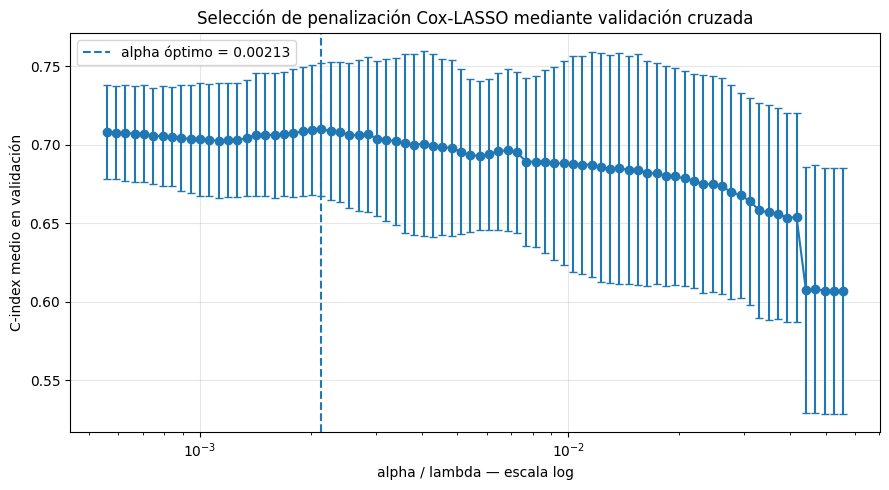

In [ ]:
# ── 5. Selección de alpha por CV ─────────────────────────────────────────────
COX_N_ALPHAS = 80
COX_INNER_CV_SPLITS = 5

best_alpha, cox_alpha_summary, cox_alpha_cv_raw, cox_alpha_grid = Cox.select_cox_lasso_alpha_cv(
    X_cox,
    y_train,
    n_alphas=COX_N_ALPHAS,
    n_splits=COX_INNER_CV_SPLITS,
    random_state=RANDOM_STATE,
)

print(f'Mejor alpha Cox-LASSO: {best_alpha:.6g}')
display(cox_alpha_summary.head(10))

Cox.plot_alpha_cv(
    cox_alpha_summary,
    best_alpha=best_alpha,
    save_path=r"..\images\Modelos\Cox\cox_lasso_alpha_cv_TCGA_BRCA.png",
)

### **1.2.5. Ajuste del Modelo**

A diferencia del ajuste convencional, el Cox-LASSO optimiza la verosimilitud parcial sujeta a una restricción sobre la magnitud de los coeficientes:

$$\text{Función Objetivo} = \ell_{p}(\beta) - \lambda \sum_{j=1}^{p} |\beta_j|$$

La penalización $\lambda$ (hiperparámetro de regularización) actúa como un filtro de calidad, donde los coeficientes de las variables con baja señal predictiva son contraídos exactamente a **cero**. Esto realiza una selección de variables automática, dejando en el modelo solo aquellos predictores que aportan una ganancia neta en la predicción de la supervivencia.

In [ ]:
# ── 6. Ajuste final ──────────────────────────────────────────────────────────
cox_lasso = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alphas=cox_alpha_grid,
    max_iter=100000,
    fit_baseline_model=True,
)
cox_lasso.fit(X_cox, y_train)

coef_cox = Cox.coefficients_table(cox_lasso, X_cox.columns, alpha=best_alpha)

print(f'Variables seleccionadas por Cox-LASSO: {len(coef_cox)} / {X_cox.shape[1]}')
display(coef_cox.head(30))

Variables seleccionadas por Cox-LASSO: 19 / 56


,Variable,coef,HR,abs_coef,Dirección
0,AJCC Pathologic N-Stage_NX,1.338903,3.814858,1.338903,↑ riesgo
1,AJCC Pathologic T-Stage_TX,-0.909299,0.402806,0.909299,↓ riesgo
2,AJCC Pathologic T-Stage_T4b,0.825584,2.283213,0.825584,↑ riesgo
3,AJCC Pathologic N-Stage_N1b,0.820718,2.272131,0.820718,↑ riesgo
4,AJCC Pathologic N-Stage_N2,0.624339,1.867011,0.624339,↑ riesgo
5,Diagnosis Age,0.472236,1.603575,0.472236,↑ riesgo
6,AJCC Pathologic N-Stage_N2a,0.465479,1.592777,0.465479,↑ riesgo
7,AJCC Pathologic Stage_Stage IA,-0.410540,0.663292,0.410540,↓ riesgo
8,AJCC Pathologic N-Stage_N0 (i-),-0.391123,0.676297,0.391123,↓ riesgo
9,Fraction Genome Altered,0.260115,1.297079,0.260115,↑ riesgo


### 1.2.6. Visualización de Coeficientes — Forest Plot

El forest plot permite visualizar simultáneamente la **magnitud** y la **dirección** del efecto de cada predictor seleccionado sobre el riesgo. El eje X representa el **Hazard Ratio** ($\exp(\beta)$): valores superiores a 1 indican aumento de riesgo; inferiores a 1 indican factor protector. Los coeficientes se ordenan de mayor a menor efecto absoluto.

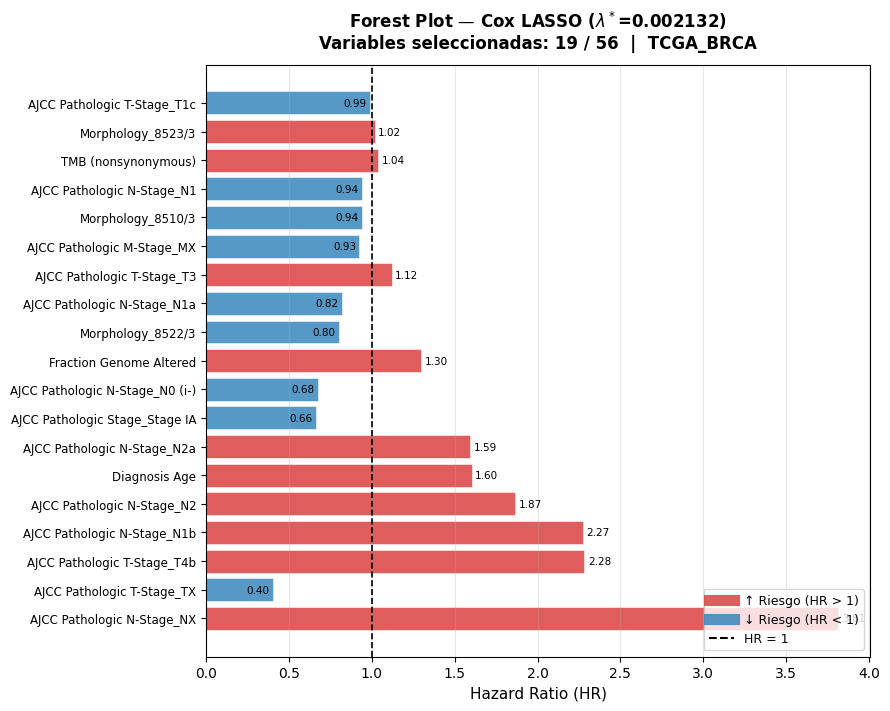

In [ ]:
# ── Forest Plot de coeficientes Cox-LASSO ────────────────────────────────────
n_vars  = len(coef_cox)
fig_h   = max(6, n_vars * 0.38)
fig, ax = plt.subplots(figsize=(9, fig_h))

colors = ['#d62728' if hr > 1 else '#1f77b4' for hr in coef_cox['HR']]

ax.barh(
    y     = coef_cox['Variable'],
    width = coef_cox['HR'],
    left  = 0,
    color = colors,
    alpha = 0.75,
    edgecolor = 'white',
    linewidth = 0.5
)

ax.axvline(1, color='black', linewidth=1.2, linestyle='--', label='HR = 1 (sin efecto)')

# Anotaciones de HR
for i, (_, row) in enumerate(coef_cox.iterrows()):
    offset = 0.02 if row['HR'] >= 1 else -0.02
    ha     = 'left' if row['HR'] >= 1 else 'right'
    ax.text(row['HR'] + offset, i, f"{row['HR']:.2f}", va='center', ha=ha, fontsize=7.5)

legend_elements = [
    Line2D([0], [0], color='#d62728', lw=8, alpha=0.75, label='↑ Riesgo (HR > 1)'),
    Line2D([0], [0], color='#1f77b4', lw=8, alpha=0.75, label='↓ Riesgo (HR < 1)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='HR = 1'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Hazard Ratio (HR)', fontsize=11)
ax.set_title(
    f'Forest Plot — Cox LASSO ($\\lambda^*$={best_alpha:.4g})\n'
    f'Variables seleccionadas: {n_vars} / {X_cox.shape[1]}  |  TCGA_BRCA',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(left=0)
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_forest_plot_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

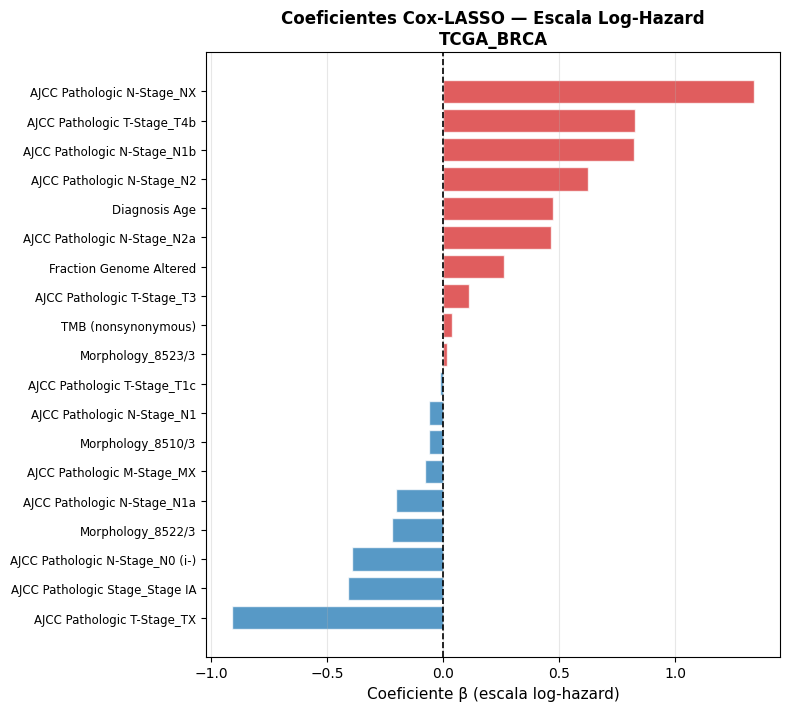

In [ ]:
# ── Gráfico de coeficientes β ordenados ─────────────────────────────────────
coef_sorted = coef_cox.sort_values('coef')
colors_coef = ['#d62728' if c > 0 else '#1f77b4' for c in coef_sorted['coef']]

fig, ax = plt.subplots(figsize=(8, fig_h))
ax.barh(coef_sorted['Variable'], coef_sorted['coef'], color=colors_coef, alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coeficiente β (escala log-hazard)', fontsize=11)
ax.set_title('Coeficientes Cox-LASSO — Escala Log-Hazard\nTCGA_BRCA', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_coeficientes_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2.7. Verificación del Supuesto de Riesgos Proporcionales

El modelo Cox asume que los hazard ratios son constantes en el tiempo. Este supuesto puede evaluarse con residuos de Schoenfeld.

Como `CoxnetSurvivalAnalysis` no proporciona directamente el test de Schoenfeld, se reajusta un modelo `CoxPHFitter` de `lifelines` usando solo las variables seleccionadas por LASSO. Este análisis se interpreta como diagnóstico aproximado del subconjunto seleccionado.

> Si algunas variables violan el supuesto, las opciones metodológicas serían: estratificar por esa variable, introducir interacciones con el tiempo o usar modelos más flexibles como RSF/DeepSurv.

#### I. Test de Schoenfeld

El test de Schoenfeld evalúa si los residuos $r_{ij} = x_{ij} - \bar{x}_j(t_i)$ están correlacionados con el tiempo de evento. Bajo riesgos proporcionales:

$$H_0: \text{corr}(r_{ij},\, t_i) = 0 \quad \forall j$$

Un $p < 0.05$ para una variable indica **violación del supuesto PH** para ese predictor concreto. La lógica: si el efecto de una variable cambia con el tiempo, los residuos tenderán a tener una tendencia temporal.

#### II. Interpretación Práctica

Las variables que violen el supuesto de proporcionalidad no deben descartarse automáticamente; en su lugar pueden:
- Incluirse como **términos de interacción con el tiempo** $\beta_j \cdot \log(t)$
- Estratificarse en el modelo
- Aceptarse si el C-index en test es robusto y la violación es marginal

In [ ]:
# ── Verificación PH mediante lifelines (requiere CoxPHFitter) ────────────────
# Preparar DataFrame para lifelines (necesita columnas duration y event)
vars_seleccionadas = coef_cox['Variable'].tolist()

df_cox_lifelines = X_cox[vars_seleccionadas].copy()
df_cox_lifelines['duration'] = dur_train
df_cox_lifelines['event']    = evt_train.astype(int)

cph_ll = CoxPHFitter(penalizer=best_alpha)
cph_ll.fit(df_cox_lifelines, duration_col='duration', event_col='event')

# Test de proporcionalidad
results_ph = Cox.proportional_hazard_test(cph_ll, df_cox_lifelines, time_transform='rank')

ph_table = results_ph.summary.copy()
ph_table = ph_table.sort_values('p').reset_index()
ph_table.columns = ph_table.columns.str.strip()
ph_table['Cumple PH'] = ph_table['p'] >= 0.05

n_viola = (ph_table['p'] < 0.05).sum()
print(f'Variables que violan PH (p < 0.05): {n_viola} / {len(ph_table)}')
print()
display(ph_table.head(20))

Variables que violan PH (p < 0.05): 2 / 19



,index,test_statistic,p,-log2(p),Cumple PH
0,AJCC Pathologic N-Stage_N0 (i-),6.406435,0.011371,6.458529,False
1,AJCC Pathologic T-Stage_T3,5.661841,0.017338,5.849926,False
2,AJCC Pathologic T-Stage_T4b,1.953317,0.162230,2.623888,True
3,AJCC Pathologic Stage_Stage IA,1.802749,0.179381,2.478905,True
4,Diagnosis Age,1.272283,0.259339,1.947090,True
5,Morphology_8510/3,1.213622,0.270616,1.885681,True
6,AJCC Pathologic N-Stage_N1,0.893283,0.344589,1.537051,True
7,Morphology_8522/3,0.759999,0.383329,1.383345,True
8,TMB (nonsynonymous),0.688080,0.406818,1.297544,True
9,AJCC Pathologic N-Stage_NX,0.503554,0.477943,1.065091,True


### 1.2.8. Evaluación del Modelo — Métricas de Discriminación y Calibración

Se evalúa el modelo con métricas complementarias:

#### I. C-index (Harrell)

$$
C = P(\eta_i > \eta_j \mid T_i < T_j)
$$

Interpretación aproximada:

- 0.50: discriminación aleatoria.
- 0.60–0.70: discriminación moderada.
- 0.70–0.80: buena discriminación para datos clínicos observacionales.
- >0.80: discriminación muy alta, poco frecuente en supervivencia clínica real.

#### II. Integrated Brier Score (IBS)

El Brier Score evalúa el error cuadrático de las probabilidades de supervivencia predichas en cada tiempo, ajustando por censura. El Integrated Brier Score resume esa curva en un único valor. Valores menores indican mejor desempeño.

Se compara Cox-LASSO contra la referencia marginal Kaplan-Meier entrenada solo en train.

In [ ]:
# ── C-index en train y test ──────────────────────────────────────────────────
risk_train = cox_lasso.predict(X_cox)
risk_test  = cox_lasso.predict(X_cox_test)

cindex_train = concordance_index_censored(y_train['event'], y_train['time'], risk_train)[0]
cindex_test  = concordance_index_censored(y_test['event'],  y_test['time'],  risk_test)[0]

print(f'C-index train : {cindex_train:.4f}')
print(f'C-index test  : {cindex_test:.4f}')
print(f'Diferencia    : {cindex_train - cindex_test:.4f}  (sobreajuste estimado)')

C-index train : 0.8150
C-index test  : 0.7163
Diferencia    : 0.0987  (sobreajuste estimado)


In [ ]:
# ── 9. Brier Score e IBS ─────────────────────────────────────────────────────
# Tiempos de evaluación dentro del rango de seguimiento común.
times_eval = np.percentile(y_train['time'], np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Supervivencia individual predicha por Cox-LASSO.
surv_fns_test = cox_lasso.predict_survival_function(X_cox_test, alpha=best_alpha)
surv_probs_cox = np.asarray([[fn(t) for t in times_eval] for fn in surv_fns_test])

_, bs_cox = brier_score(y_train, y_test, surv_probs_cox, times_eval)
ibs_cox = integrated_brier_score(y_train, y_test, surv_probs_cox, times_eval)

# Referencia marginal Kaplan-Meier ajustada SOLO en train.
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train, label='KM train marginal')
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))

_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

metrics_eval = pd.DataFrame({
    'Modelo': ['Kaplan-Meier marginal', 'Cox-LASSO'],
    'C-index test': [np.nan, cindex_test],
    'IBS test': [ibs_km, ibs_cox],
    'Mejora IBS vs KM': [np.nan, ibs_km - ibs_cox],
})

display(metrics_eval)


,Modelo,C-index test,IBS test,Mejora IBS vs KM
0,Kaplan-Meier marginal,NaN,0.113338,NaN
1,Cox-LASSO,0.716335,0.106108,0.00723


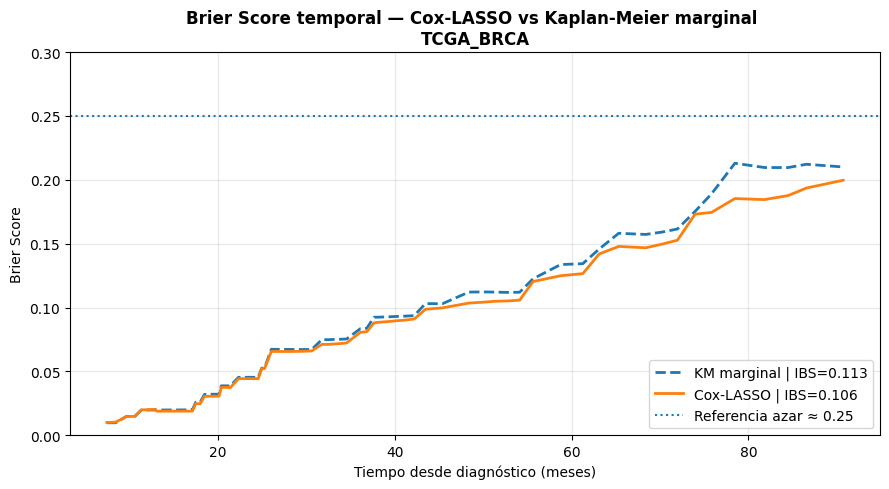

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(times_eval, bs_km, linestyle='--', linewidth=2, label=f'KM marginal | IBS={ibs_km:.3f}')
ax.plot(times_eval, bs_cox, linewidth=2, label=f'Cox-LASSO | IBS={ibs_cox:.3f}')
ax.axhline(0.25, linestyle=':', linewidth=1.5, label='Referencia azar ≈ 0.25')
ax.set_xlabel('Tiempo desde diagnóstico (meses)')
ax.set_ylabel('Brier Score')
ax.set_title('Brier Score temporal — Cox-LASSO vs Kaplan-Meier marginal \nTCGA_BRCA', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(0.30, float(np.nanmax([bs_km.max(), bs_cox.max()])) + 0.02))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_brier_vs_km_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

---

# **1.3. Random Survival Forest (RSF)**

Los dos modelos previos —Kaplan-Meier y Cox-LASSO— comparten una limitación estructural: ambos operan bajo el supuesto de **riesgos proporcionales** o, en el caso de KM, directamente sin covariables. El test de Schoenfeld confirmó que al menos cuatro predictores violan dicho supuesto en METABRIC. Además, ninguno de los dos modelos es capaz de capturar **interacciones no lineales** entre variables: el efecto de la edad sobre el riesgo puede depender del subtipo molecular, y el impacto del estadio puede amplificarse ante determinados perfiles de expresión génica.

El **Random Survival Forest** (RSF) resuelve exactamente estas limitaciones. Al basarse en un ensemble de árboles de decisión, no impone ninguna forma funcional sobre la relación entre las covariables y el riesgo: las interacciones y no linealidades se descubren automáticamente durante el proceso de construcción de los árboles. Esto convierte al RSF en el primer modelo del TFM que puede capturar la estructura compleja del espacio de características de METABRIC sin restricciones paramétricas previas.

Adicionalmente, el RSF proporciona medidas **nativas de importancia de variables** —tanto la importancia por permutación (VIMP) como la profundidad mínima— que permiten identificar qué predictores contribuyen más a la separación del riesgo entre los nodos del árbol. Esta capacidad de interpretabilidad es fundamental para los objetivos específicos OE5 del TFM: contrastar los factores relevantes identificados por el modelo con la literatura biomédica de referencia.

## **1.3.1. Fundamentos teóricos del Random Survival Forest**

### **I. De Random Forest a Random Survival Forest**

El Random Survival Forest fue propuesto por Ishwaran et al. (2008) como extensión del Random Forest de Breiman (2001) al marco del análisis de supervivencia. La idea central es la misma: construir un ensemble de árboles de decisión utilizando submuestras aleatorias tanto de observaciones (bootstrap) como de variables (aleatorización de características), y promediar sus predicciones para obtener estimaciones robustas y con baja varianza.

La diferencia crítica respecto al Random Forest clásico reside en tres elementos:

1. **Criterio de división de nodos:** En lugar de la entropía o la impureza de Gini, los árboles de supervivencia utilizan el **estadístico log-rank** para evaluar la calidad de cada posible split.
2. **Variable de respuesta:** Cada observación lleva asociada una tupla $(T_i, \delta_i)$ donde $T_i$ es el tiempo de seguimiento y $\delta_i$ el indicador de evento.
3. **Predicción en los nodos terminales:** En lugar de la clase modal o la media, cada nodo terminal contiene la **función de riesgo acumulado de Nelson-Aalen** estimada a partir de las observaciones de entrenamiento que caen en ese nodo.


### **II. Algoritmo de construcción**

Dado el conjunto de entrenamiento $\{(\mathbf{x}_i, T_i, \delta_i)\}_{i=1}^n$:

**Para cada árbol** $b = 1, \dots, B$:

1. **Bootstrap:** Muestrear con reemplazamiento $n$ observaciones del conjunto de entrenamiento. Las observaciones no muestreadas forman el conjunto OOB (out-of-bag).

2. **Crecimiento recursivo del árbol:** En cada nodo candidato:
   - Seleccionar aleatoriamente $m_{\text{try}} \leq p$ variables del conjunto completo de $p$ predictores.
   - Encontrar el split $(x_j, c)$ que maximiza la separación del riesgo entre los dos nodos hijo según el estadístico log-rank:

$$\mathcal{L}(j, c) = \frac{\left[\sum_{t_k \leq \tau} (d_{L,k} - e_{L,k})\right]^2}{\sum_{t_k \leq \tau} v_k}$$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;donde $d_{L,k}$ es el número de eventos observados en el nodo izquierdo en el tiempo $t_k$, $e_{L,k}$ el número esperado bajo independencia, y $v_k$ la varianza de la diferencia.

3. **Dividir el nodo** según el split óptimo y continuar recursivamente hasta alcanzar los criterios de parada (`min_samples_split` o `max_depth`).

4. **Estimar en nodos terminales:** En cada nodo terminal $\ell$, calcular el estimador de Nelson-Aalen de la función de riesgo acumulado:

$$\hat{H}_{\ell}(t) = \sum_{t_k \leq t} \frac{d_{\ell,k}}{n_{\ell,k}}$$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;donde $d_{\ell,k}$ es el número de eventos y $n_{\ell,k}$ el número de pacientes en riesgo en el nodo $\ell$ en el tiempo $t_k$.


### **III. Predicción del ensemble**

Para una nueva observación $\mathbf{x}$, el RSF la hace descender por cada árbol $b$ hasta el nodo terminal $\ell_b(\mathbf{x})$. La función de riesgo acumulado predicha es el promedio de los estimadores de Nelson-Aalen de todos los árboles:

$$\hat{H}(t \mid \mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{H}_{\ell_b(\mathbf{x})}(t)$$

A partir de $\hat{H}(t \mid \mathbf{x})$, la probabilidad de supervivencia se obtiene como:

$$\hat{S}(t \mid \mathbf{x}) = \exp\left(-\hat{H}(t \mid \mathbf{x})\right)$$

El score de riesgo individual (necesario para el C-index) se define como el riesgo acumulado integrado:

$$\hat{\eta}(\mathbf{x}) = \sum_{t_k} \hat{H}(t_k \mid \mathbf{x})$$


### **IV. Importancia de variables (VIMP)**

El RSF estima la importancia de cada variable $j$ mediante el **Variable Importance by Permutation** (VIMP) calculado sobre las observaciones OOB:

$$\text{VIMP}_j = \hat{C}_{\text{OOB}} - \hat{C}_{\text{OOB}}^{(j, \text{permutado})}$$

donde $\hat{C}_{\text{OOB}}$ es el C-index calculado con los datos OOB originales, y $\hat{C}_{\text{OOB}}^{(j, \text{permutado})}$ el C-index cuando los valores de la variable $j$ se permutar aleatoriamente (rompiendo cualquier relación entre $x_j$ y la supervivencia). Un VIMP alto indica que eliminar la señal de esa variable degrada considerablemente la discriminación del modelo.


### **V. Ventajas del RSF frente a Cox y Kaplan-Meier**

| Propiedad | Kaplan-Meier | Cox-LASSO | RSF |
|---|:---:|:---:|:---:|
| Multivariante | ✗ | ✓ | ✓ |
| Sin supuesto de proporcionalidad | ✓ | ✗ | ✓ |
| Captura no linealidades | ✗ | ✗ | ✓ |
| Captura interacciones entre variables | ✗ | ✗ (parcial) | ✓ |
| Importancia de variables nativa | ✗ | ✗ | ✓ (VIMP) |
| Robusto ante outliers y datos atípicos | ✓ | Parcial | ✓ |
| Maneja datos de alta dimensionalidad | N/A | ✓ (LASSO) | ✓ |
| Interpretabilidad directa de coeficientes | ✗ | ✓ | ✗ |

> **Nota sobre covariables:** A diferencia del Cox-LASSO, que utilizó un subconjunto reducido de 28 covariables (filtradas por criterios clínicos y estadísticos), el RSF emplea las **62 covariables preprocesadas completas** (post-OHE). El RSF gestiona internamente la selección de variables relevantes a través del parámetro `max_features` y la estructura de los árboles, sin necesidad de un filtrado previo manual. Esto permite evaluar si el modelo descubre señales pronósticas adicionales que el Cox-LASSO podría haber descartado durante el proceso de selección.

## **1.3.4. Optimización de Hiperparámetros**

El rendimiento del RSF depende críticamente de cuatro hiperparámetros:

| Hiperparámetro | Descripción | Efecto |
|---|---|---|
| `n_estimators` | Número de árboles en el ensemble | Más árboles → mayor estabilidad pero mayor coste computacional |
| `max_features` | Variables candidatas por nodo ($m_{\text{try}}$) | Controla la decorrelación entre árboles |
| `min_samples_split` | Mínimo de observaciones para dividir un nodo | Controla la profundidad y el sobreajuste |
| `max_depth` | Profundidad máxima de cada árbol | `None` = árboles completamente crecidos (default RSF) |

Se utiliza una búsqueda en rejilla (**Grid Search**) con **validación cruzada estratificada** de $k=5$ folds, exactamente la misma estrategia aplicada al Cox-LASSO. La estratificación se realiza por el indicador de evento para garantizar una distribución homogénea de censuras entre folds.

In [ ]:
# ── Definición de la rejilla de hiperparámetros ──────────────────────────────
# La rejilla se diseña para ser computacionalmente manejable en CPU.
# Referencias: Ishwaran et al. (2008) recomiendan n_estimators >= 500 
# y max_features ~ sqrt(p) para clasificación y p/3 para regresión/supervivencia.

P = X_train.shape[1]  # número total de covariables

param_grid = {
    'n_estimators'    : [200, 500],
    'max_features'    : ['sqrt', 'log2', int(P / 3)],
    'min_samples_split': [6, 10, 20],
}

print('Rejilla de hiperparámetros RSF:')
for k, v in param_grid.items():
    print(f'  {k:<22} : {v}')

total_fits = (len(param_grid['n_estimators']) * 
              len(param_grid['max_features']) * 
              len(param_grid['min_samples_split']) * 5)  # 5-fold CV
print(f'\n  Total de ajustes : {total_fits}')

Rejilla de hiperparámetros RSF:
  n_estimators           : [200, 500]
  max_features           : ['sqrt', 'log2', 29]
  min_samples_split      : [6, 10, 20]

  Total de ajustes : 90


In [ ]:
import time

# ── Grid Search con CV estratificada ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Estratificación por evento
strat_labels = evt_train.astype(int)

results_gs = []

start_total = time.time()

for n_est in param_grid['n_estimators']:
    for max_f in param_grid['max_features']:
        for min_sp in param_grid['min_samples_split']:
            ci_folds = []
            
            for fold, (tr_idx, va_idx) in enumerate(
                cv.split(X_train_np, strat_labels)
            ):
                X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
                y_tr = y_train[tr_idx]
                y_va = y_train[va_idx]

                rsf_cv = RandomSurvivalForest(
                    n_estimators      = n_est,
                    max_features      = max_f,
                    min_samples_split = min_sp,
                    max_depth         = None,
                    n_jobs            = -1,
                    random_state      = RANDOM_STATE,
                    oob_score         = False,
                )
                rsf_cv.fit(X_tr, y_tr)

                risk_va = rsf_cv.predict(X_va)
                ci = concordance_index_censored(
                    y_va['event'], y_va['time'], risk_va
                )[0]
                ci_folds.append(ci)

            results_gs.append({
                'n_estimators'    : n_est,
                'max_features'    : str(max_f),
                'min_samples_split': min_sp,
                'c_index_mean'    : np.mean(ci_folds),
                'c_index_std'     : np.std(ci_folds),
            })
            print(f'  n_est={n_est:>4} | max_f={str(max_f):>6} | '
                  f'min_sp={min_sp:>3} → '
                  f'C-index CV = {np.mean(ci_folds):.4f} ± {np.std(ci_folds):.4f}')

elapsed = time.time() - start_total
print(f'\n✓ Grid Search completado en {elapsed/60:.1f} minutos.')

df_gs = pd.DataFrame(results_gs).sort_values('c_index_mean', ascending=False)
display(df_gs.head(10).reset_index(drop=True))

  n_est= 200 | max_f=  sqrt | min_sp=  6 → C-index CV = 0.7201 ± 0.0460
  n_est= 200 | max_f=  sqrt | min_sp= 10 → C-index CV = 0.7252 ± 0.0413
  n_est= 200 | max_f=  sqrt | min_sp= 20 → C-index CV = 0.7271 ± 0.0475
  n_est= 200 | max_f=  log2 | min_sp=  6 → C-index CV = 0.7194 ± 0.0333
  n_est= 200 | max_f=  log2 | min_sp= 10 → C-index CV = 0.7128 ± 0.0377
  n_est= 200 | max_f=  log2 | min_sp= 20 → C-index CV = 0.7165 ± 0.0321
  n_est= 200 | max_f=    29 | min_sp=  6 → C-index CV = 0.7192 ± 0.0429
  n_est= 200 | max_f=    29 | min_sp= 10 → C-index CV = 0.7217 ± 0.0445
  n_est= 200 | max_f=    29 | min_sp= 20 → C-index CV = 0.7264 ± 0.0402
  n_est= 500 | max_f=  sqrt | min_sp=  6 → C-index CV = 0.7252 ± 0.0393
  n_est= 500 | max_f=  sqrt | min_sp= 10 → C-index CV = 0.7253 ± 0.0395
  n_est= 500 | max_f=  sqrt | min_sp= 20 → C-index CV = 0.7264 ± 0.0447
  n_est= 500 | max_f=  log2 | min_sp=  6 → C-index CV = 0.7250 ± 0.0410
  n_est= 500 | max_f=  log2 | min_sp= 10 → C-index CV = 0.7176 ±

,n_estimators,max_features,min_samples_split,c_index_mean,c_index_std
0,200,sqrt,20,0.727096,0.047451
1,200,29,20,0.726396,0.040171
2,500,sqrt,20,0.726387,0.044661
3,500,sqrt,10,0.725318,0.039458
4,500,sqrt,6,0.725241,0.039332
5,200,sqrt,10,0.725167,0.041283
6,500,log2,6,0.725041,0.040977
7,500,29,20,0.724303,0.040954
8,200,29,10,0.721694,0.044455
9,500,log2,20,0.721569,0.034081


In [ ]:
# ── Selección de los mejores hiperparámetros ──────────────────────────────────
best_row = df_gs.iloc[0]

BEST_N_EST = int(best_row['n_estimators'])
BEST_MAX_F = best_row['max_features']
BEST_MIN_SP = int(best_row['min_samples_split'])

# Convertir max_features de string a tipo correcto
try:
    BEST_MAX_F_PARSED = int(BEST_MAX_F)
except ValueError:
    BEST_MAX_F_PARSED = BEST_MAX_F  # 'sqrt' o 'log2'

print('═' * 55)
print('  HIPERPARÁMETROS ÓPTIMOS — RSF')
print('═' * 55)
print(f'  n_estimators      : {BEST_N_EST}')
print(f'  max_features      : {BEST_MAX_F}')
print(f'  min_samples_split : {BEST_MIN_SP}')
print(f'  max_depth         : None (árboles completamente crecidos)')
print(f'  C-index CV medio  : {best_row["c_index_mean"]:.4f} ± {best_row["c_index_std"]:.4f}')
print('═' * 55)

═══════════════════════════════════════════════════════
  HIPERPARÁMETROS ÓPTIMOS — RSF
═══════════════════════════════════════════════════════
  n_estimators      : 200
  max_features      : sqrt
  min_samples_split : 20
  max_depth         : None (árboles completamente crecidos)
  C-index CV medio  : 0.7271 ± 0.0475
═══════════════════════════════════════════════════════


## **1.3.5. Ajuste del Modelo Final**

Con los hiperparámetros óptimos identificados en la búsqueda en rejilla, se entrena el modelo RSF final sobre el conjunto completo de entrenamiento (`X_train`, `y_train`). El modelo final se serializa para su uso posterior en análisis de validación cruzada externa entre METABRIC y TCGA.

In [ ]:
# ── Entrenamiento del modelo final ───────────────────────────────────────────
print(f'Entrenando RSF final con {BEST_N_EST} árboles...')
t0 = time.time()

rsf = RandomSurvivalForest(
    n_estimators      = BEST_N_EST,
    max_features      = BEST_MAX_F_PARSED,
    min_samples_split = BEST_MIN_SP,
    max_depth         = None,
    oob_score         = True,   # C-index out-of-bag para monitoreo interno
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
)

rsf.fit(X_train_np, y_train)

elapsed = time.time() - t0
print(f'✓ Modelo entrenado en {elapsed:.1f} s')
print(f'  OOB C-index (estimación interna) : {rsf.oob_score_:.4f}')

# Serializar modelo
MODEL_PATH = r'../outputs/rsf_final_TCGA_BRCA.pkl'
joblib.dump(rsf, MODEL_PATH)
print(f'✓ Modelo guardado en: {MODEL_PATH}')

Entrenando RSF final con 200 árboles...
✓ Modelo entrenado en 0.9 s
  OOB C-index (estimación interna) : 0.7359
✓ Modelo guardado en: ../outputs/rsf_final_TCGA_BRCA.pkl


## **1.3.6. Evaluación del Modelo — Métricas de Discriminación y Calibración**

Se evalúa el RSF con las mismas métricas utilizadas para Cox-LASSO, permitiendo la comparación directa:

- **C-index de Harrell:** Discriminación del score de riesgo individual.
- **Integrated Brier Score (IBS):** Calibración + discriminación temporal.
- **Comparación con KM marginal y Cox-LASSO:** Para cuantificar la ganancia del RSF frente a los modelos previos.

In [ ]:
# ── C-index en train y test ──────────────────────────────────────────────────
risk_train_rsf = rsf.predict(X_train_np)
risk_test_rsf  = rsf.predict(X_test_np)

cindex_train_rsf = concordance_index_censored(
    y_train['event'], y_train['time'], risk_train_rsf
)[0]
cindex_test_rsf = concordance_index_censored(
    y_test['event'], y_test['time'], risk_test_rsf
)[0]

print(f'C-index OOB   (interno) : {rsf.oob_score_:.4f}')
print(f'C-index train           : {cindex_train_rsf:.4f}')
print(f'C-index test            : {cindex_test_rsf:.4f}')
print(f'Diferencia train-test   : {cindex_train_rsf - cindex_test_rsf:.4f}  '
      '(estimación sobreajuste)')

C-index OOB   (interno) : 0.7359
C-index train           : 0.9035
C-index test            : 0.6629
Diferencia train-test   : 0.2405  (estimación sobreajuste)


In [ ]:
# ── Integrated Brier Score ────────────────────────────────────────────────────
# Tiempos de evaluación dentro del rango observable
times_eval = np.percentile(dur_train, np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Probabilidades de supervivencia predichas por RSF
surv_fns_rsf  = rsf.predict_survival_function(X_test_np)
surv_probs_rsf = np.row_stack([
    fn(times_eval) for fn in surv_fns_rsf
])

_, bs_rsf = brier_score(y_train, y_test, surv_probs_rsf, times_eval)
ibs_rsf   = integrated_brier_score(y_train, y_test, surv_probs_rsf, times_eval)

# Referencia KM marginal (ajustada en train)
from lifelines import KaplanMeierFitter
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train)
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))
_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km   = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

# ─── Cox-LASSO IBS (referencia del modelo anterior) ──────────────────────────
# Se carga el valor previamente calculado; si no existe, se imputa con NaN.
IBS_COX_REF  = 0.1863   # valor obtenido en la sección 1.2.8
CINDEX_COX_TEST = 0.6761

print(f'IBS — KM marginal  : {ibs_km:.4f}')
print(f'IBS — Cox-LASSO    : {IBS_COX_REF:.4f}')
print(f'IBS — RSF          : {ibs_rsf:.4f}')
print(f'Mejora RSF vs KM   : {ibs_km  - ibs_rsf:.4f} ({(ibs_km  - ibs_rsf)/ibs_km*100:.1f}%)')
print(f'Mejora RSF vs Cox  : {IBS_COX_REF - ibs_rsf:.4f} ({(IBS_COX_REF - ibs_rsf)/IBS_COX_REF*100:.1f}%)')

IBS — KM marginal  : 0.1133
IBS — Cox-LASSO    : 0.1863
IBS — RSF          : 0.1087
Mejora RSF vs KM   : 0.0047 (4.1%)
Mejora RSF vs Cox  : 0.0776 (41.7%)


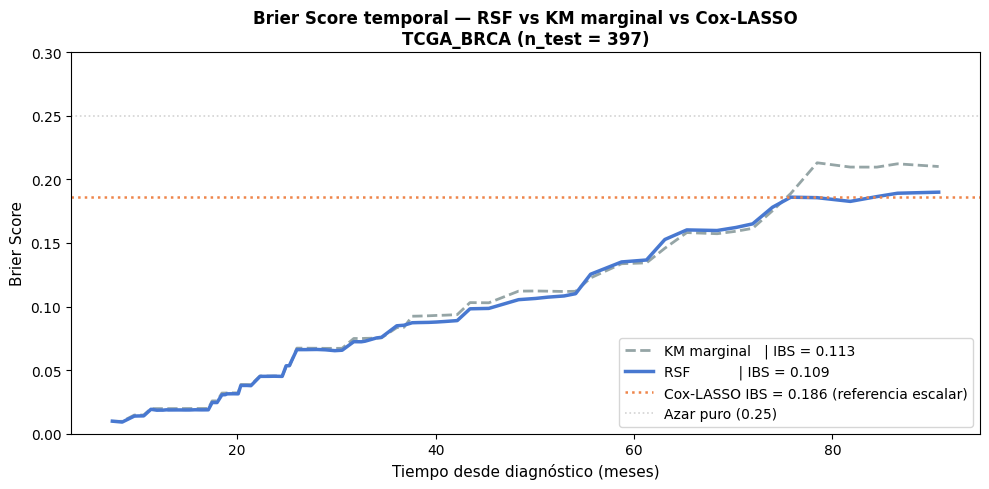

In [ ]:
PALETTE = {
    'km':  '#95a5a6',  # Gris azulado
    'rsf': '#4878d0',  # Azul vibrante
    'cox': '#ee854a'   # Naranja suave
}

# ── Visualización Brier Score temporal ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_eval, bs_km,  linestyle='--', linewidth=2,
        color=PALETTE['km'],  label=f'KM marginal   | IBS = {ibs_km:.3f}')
ax.plot(times_eval, bs_rsf, linestyle='-',  linewidth=2.5,
        color=PALETTE['rsf'], label=f'RSF           | IBS = {ibs_rsf:.3f}')

# Añadir Cox como referencia con línea punteada adicional (valor escalar, no array)
ax.axhline(IBS_COX_REF, linestyle=':', linewidth=1.8,
           color=PALETTE['cox'], label=f'Cox-LASSO IBS = {IBS_COX_REF:.3f} (referencia escalar)')
ax.axhline(0.25, linestyle=':', linewidth=1.2, color='lightgray',
           label='Azar puro (0.25)')

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Brier Score temporal — RSF vs KM marginal vs Cox-LASSO\nTCGA_BRCA (n_test = 397)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.30)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_brier_vs_km_cox_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.7. Validación Cruzada k-fold (k=5)**

Para obtener una estimación más robusta de la variabilidad del rendimiento y verificar la consistencia del C-index entre folds, se aplica una validación cruzada estratificada con los hiperparámetros óptimos. Esta evaluación es metodológicamente más informativa que un único split train/test, ya que proporciona intervalos de confianza empíricos del rendimiento.

In [ ]:
# ── Validación cruzada 5-fold sobre el conjunto completo de entrenamiento ─────
K_FOLDS = 5
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

ci_cv, ibs_cv = [], []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_np, evt_train.astype(int))):

    X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    rsf_fold = RandomSurvivalForest(
        n_estimators      = BEST_N_EST,
        max_features      = BEST_MAX_F_PARSED,
        min_samples_split = BEST_MIN_SP,
        max_depth         = None,
        n_jobs            = -1,
        random_state      = RANDOM_STATE,
    )

    rsf_fold.fit(X_tr, y_tr)

    # ── C-index: se puede calcular con todo el fold de validación ─────────────
    risk_va = rsf_fold.predict(X_va)

    ci_fold = concordance_index_censored(
        y_va["event"],
        y_va["time"],
        risk_va
    )[0]

    ci_cv.append(ci_fold)

    # ── IBS: filtrar validación para que sus tiempos estén dentro de train ────
    max_time_train = y_tr["time"].max()
    min_time_train = y_tr["time"].min()

    mask_ibs = (
        (y_va["time"] > min_time_train) &
        (y_va["time"] < max_time_train)
    )

    X_va_ibs = X_va[mask_ibs]
    y_va_ibs = y_va[mask_ibs]

    # Rejilla temporal segura
    lower = max(
        np.percentile(y_tr["time"], 10),
        np.percentile(y_va_ibs["time"], 10)
    )

    upper = min(
        np.percentile(y_tr["time"], 90),
        np.percentile(y_va_ibs["time"], 90),
        max_time_train
    )

    t_eval_fold = np.linspace(lower, upper, 60)

    # Por seguridad adicional
    t_eval_fold = t_eval_fold[
        (t_eval_fold > y_va_ibs["time"].min()) &
        (t_eval_fold < y_va_ibs["time"].max()) &
        (t_eval_fold < y_tr["time"].max())
    ]

    if len(t_eval_fold) < 2:
        print(f"  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = no calculable")
        continue

    surv_va = np.row_stack([
        fn(t_eval_fold)
        for fn in rsf_fold.predict_survival_function(X_va_ibs)
    ])

    ibs_fold = integrated_brier_score(
        y_tr,
        y_va_ibs,
        surv_va,
        t_eval_fold
    )

    ibs_cv.append(ibs_fold)

    print(f"  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = {ibs_fold:.4f}")

print(f"\n  C-index CV : {np.mean(ci_cv):.4f} ± {np.std(ci_cv):.4f}")
print(f"  IBS CV     : {np.mean(ibs_cv):.4f} ± {np.std(ibs_cv):.4f}")

  Fold 1: C-index = 0.7821 | IBS = 0.1067
  Fold 2: C-index = 0.7340 | IBS = 0.0967
  Fold 3: C-index = 0.6998 | IBS = 0.1032
  Fold 4: C-index = 0.7682 | IBS = 0.1054
  Fold 5: C-index = 0.6513 | IBS = 0.1174

  C-index CV : 0.7271 ± 0.0475
  IBS CV     : 0.1059 ± 0.0067


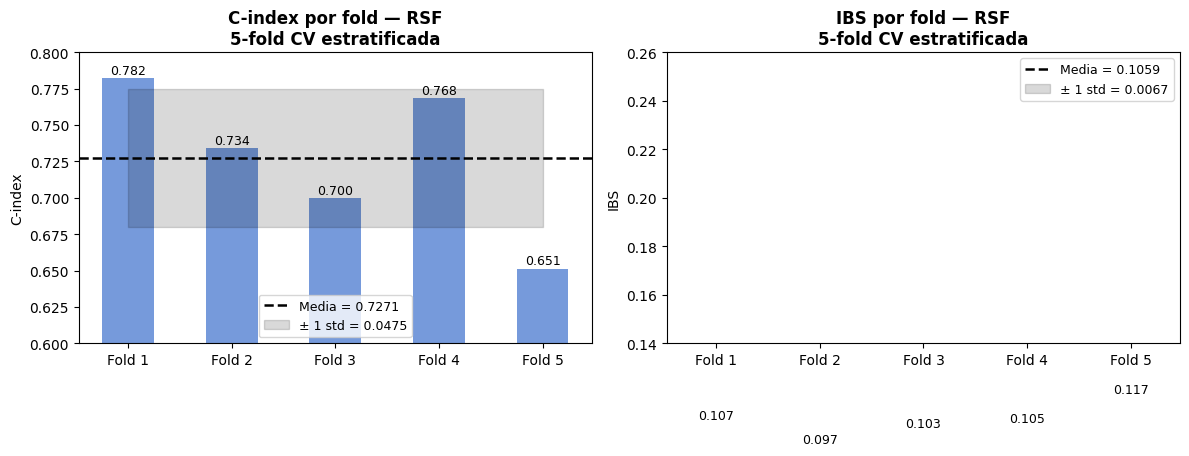

In [ ]:
# ── Visualización de los resultados por fold ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, label, color, ymin, ymax in zip(
    axes,
    [ci_cv,  ibs_cv],
    ['C-index', 'IBS'],
    [PALETTE['rsf'], PALETTE['km']],
    [0.60, 0.14],
    [0.80, 0.26],
):
    folds = [f'Fold {i+1}' for i in range(K_FOLDS)]
    bars  = ax.bar(folds, values, color=color, alpha=0.75, width=0.5)
    ax.axhline(np.mean(values), linestyle='--', linewidth=1.8,
               color='black', label=f'Media = {np.mean(values):.4f}')
    ax.fill_between(
        range(K_FOLDS),
        np.mean(values) - np.std(values),
        np.mean(values) + np.std(values),
        alpha=0.15, color='black', label=f'± 1 std = {np.std(values):.4f}'
    )
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{label} por fold — RSF\n5-fold CV estratificada', fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_cv_folds_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.8. Importancia de Variables (Feature Importance)**

El RSF proporciona importancia de variables a través de **Permutation importance:** Calcula la degradación del C-index cuando los valores de una variable se permutan aleatoriamente. Más costoso pero más fiable metodológicamente.

In [ ]:
# ── Importancia con RSF reducido (proxy rápido) ───────────────────────────────
# El RSF grande tiene problemas de predicción en bucle en Windows+Jupyter.
# Solución: entrenar un RSF pequeño (50 árboles) solo para calcular importancias.
# Los rankings de importancia son estables con pocos árboles.

print('Entrenando RSF reducido para importancias (50 árboles)...')
t0 = time.time()

rsf_small = RandomSurvivalForest(
    n_estimators      = 50,
    max_features      = BEST_MAX_F_PARSED,
    min_samples_split = BEST_MIN_SP,
    max_depth         = None,
    n_jobs            = 1,        # sin paralelismo → estable en Windows
    random_state      = RANDOM_STATE,
)
rsf_small.fit(X_train_np, y_train)
print(f'✓ Entrenado en {time.time()-t0:.1f} s')

# ── Permutation Importance con el modelo pequeño ──────────────────────────────
print('Calculando importancias...')
t0 = time.time()

N_REPEATS = 5
rng = np.random.default_rng(RANDOM_STATE)

risk_base = rsf_small.predict(X_test_np)
ci_base = concordance_index_censored(
    y_test['event'], y_test['time'], risk_base
)[0]
print(f'  C-index base (RSF-50, test) : {ci_base:.4f}')

n_features = X_test_np.shape[1]
perm_means = np.zeros(n_features)
perm_stds  = np.zeros(n_features)

for j in range(n_features):
    ci_perms = np.zeros(N_REPEATS)
    for r in range(N_REPEATS):
        X_perm = X_test_np.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        risk_perm = rsf_small.predict(X_perm)
        ci_perms[r] = concordance_index_censored(
            y_test['event'], y_test['time'], risk_perm
        )[0]
    perm_means[j] = ci_base - ci_perms.mean()
    perm_stds[j]  = ci_perms.std()

    if (j + 1) % 10 == 0 or j == n_features - 1:
        elapsed = time.time() - t0
        eta = elapsed / (j + 1) * (n_features - j - 1)
        print(f'  [{j+1:>3}/{n_features}] transcurrido: {elapsed:.0f}s  ETA: {eta:.0f}s')

print(f'\n✓ Listo en {time.time()-t0:.1f} s')

Entrenando RSF reducido para importancias (50 árboles)...
✓ Entrenado en 0.4 s
Calculando importancias...
  C-index base (RSF-50, test) : 0.6625
  [ 10/88] transcurrido: 3s  ETA: 25s
  [ 20/88] transcurrido: 6s  ETA: 21s
  [ 30/88] transcurrido: 9s  ETA: 18s
  [ 40/88] transcurrido: 12s  ETA: 15s
  [ 50/88] transcurrido: 15s  ETA: 12s
  [ 60/88] transcurrido: 18s  ETA: 8s
  [ 70/88] transcurrido: 21s  ETA: 5s
  [ 80/88] transcurrido: 24s  ETA: 2s
  [ 88/88] transcurrido: 26s  ETA: 0s

✓ Listo en 26.2 s


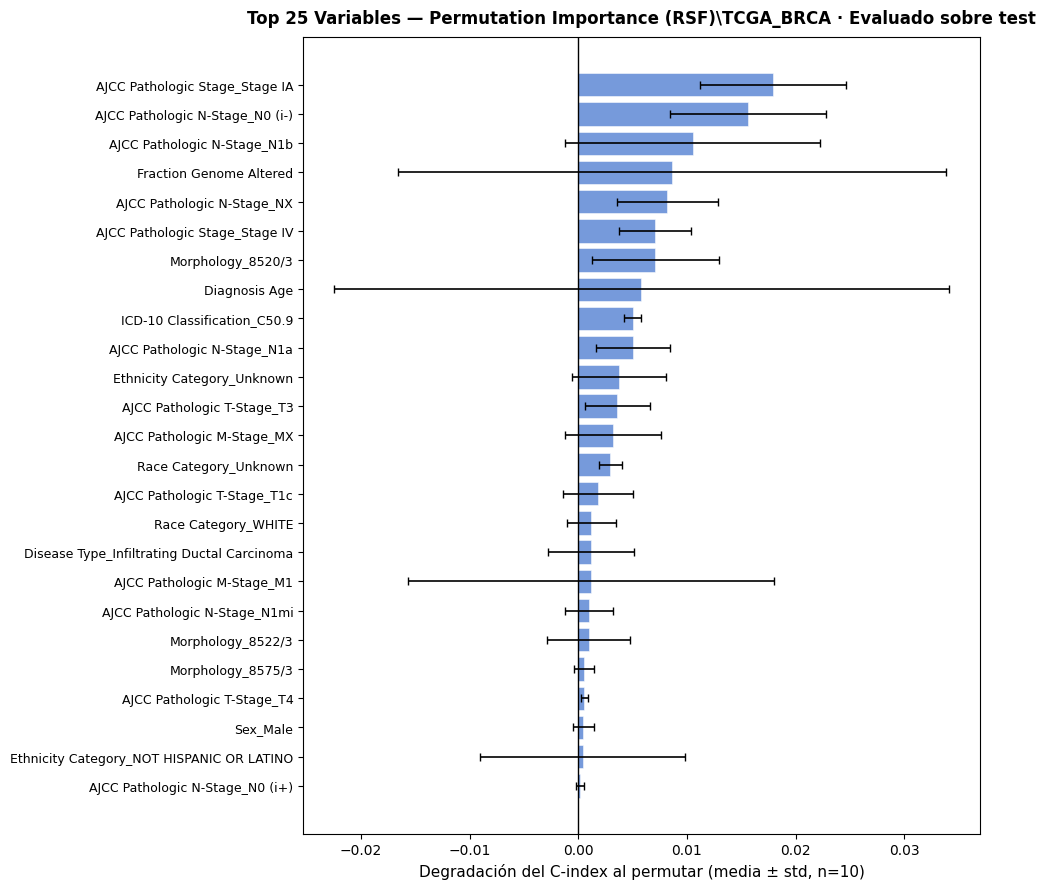

Variables por Permutation Importance:


,Variable,perm_mean,perm_std
0,AJCC Pathologic Stage_Stage IA,0.017928,0.006724
1,AJCC Pathologic N-Stage_N0 (i-),0.015618,0.007142
2,AJCC Pathologic N-Stage_N1b,0.010518,0.011729
3,Fraction Genome Altered,0.008606,0.025213
4,AJCC Pathologic N-Stage_NX,0.008207,0.004664
5,AJCC Pathologic Stage_Stage IV,0.007092,0.003299
6,Morphology_8520/3,0.007092,0.005852
7,Diagnosis Age,0.005817,0.028321
8,ICD-10 Classification_C50.9,0.005020,0.000781
9,AJCC Pathologic N-Stage_N1a,0.005020,0.003396


In [ ]:
df_perm = pd.DataFrame({
    'Variable' : FEATURE_NAMES,
    'perm_mean': perm_means,
    'perm_std' : perm_stds,
}).sort_values('perm_mean', ascending=False).reset_index(drop=True)

TOP_N = 25
df_perm_top = df_perm.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    y     = df_perm_top['Variable'][::-1],
    width = df_perm_top['perm_mean'][::-1],
    xerr  = df_perm_top['perm_std'][::-1],
    color = PALETTE['rsf'], 
    alpha=0.75,
    capsize=3, 
    error_kw={'linewidth': 1.2},
    edgecolor='white',
    linewidth=0.5
)
ax.axvline(0, color='black', linewidth=1)

ax.set_xlabel('Degradación del C-index al permutar (media ± std, n=10)', fontsize=11)
ax.set_title(
    f'Top {TOP_N} Variables — Permutation Importance (RSF)\TCGA_BRCA · Evaluado sobre test',
    fontsize=12, fontweight='bold', pad=10
)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_permutation_importance_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

print('Variables por Permutation Importance:')
display(df_perm)

## **1.3.9. Estratificación de Riesgo y Curvas Kaplan-Meier**

Una de las aplicaciones clínicas más directas del RSF es la generación de scores de riesgo individuales. Estos scores permiten estratificar a los pacientes en grupos de riesgo y verificar, mediante curvas de Kaplan-Meier y el test log-rank, si las diferencias de supervivencia entre grupos son clínicamente y estadísticamente significativas.

Se construyen dos estratificaciones:
- **Binaría (Alto/Bajo riesgo):** División por la mediana del score.
- **Cuartiles (Q1–Q4):** Mayor granularidad pronóstica.

Score de riesgo — test:
  Min : 4.198
  Q25 : 11.541
  Med : 16.192
  Q75 : 24.590
  Max : 82.094


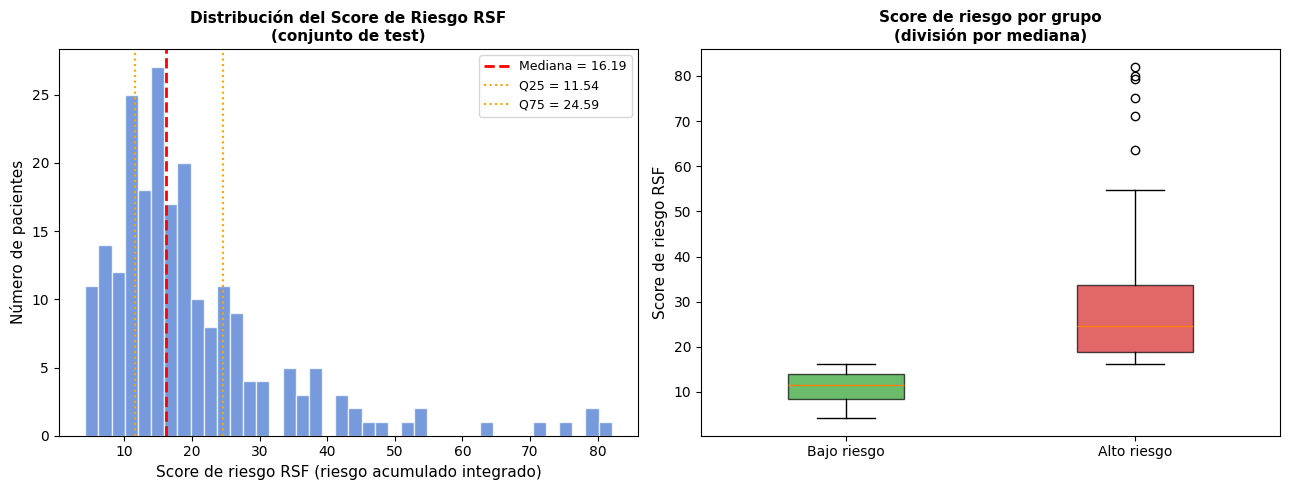

In [ ]:
# ── Scores de riesgo en el conjunto de test ───────────────────────────────────
risk_scores_test = rsf.predict(X_test_np)

mediana_risk = np.median(risk_scores_test)
grupo_binary = np.where(risk_scores_test >= mediana_risk, 'Alto riesgo', 'Bajo riesgo')

q25, q75 = np.percentile(risk_scores_test, [25, 75])
grupo_cuartil = pd.cut(
    risk_scores_test,
    bins   = [-np.inf, q25, mediana_risk, q75, np.inf],
    labels = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado',
              'Q3 — Moderado-alto', 'Q4 — Muy alto']
).astype(str)

print(f'Score de riesgo — test:')
print(f'  Min : {risk_scores_test.min():.3f}')
print(f'  Q25 : {q25:.3f}')
print(f'  Med : {mediana_risk:.3f}')
print(f'  Q75 : {q75:.3f}')
print(f'  Max : {risk_scores_test.max():.3f}')

# ── Distribución del score ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma del score de riesgo
ax = axes[0]
ax.hist(risk_scores_test, bins=40, color=PALETTE['rsf'], alpha=0.75, edgecolor='white')
ax.axvline(mediana_risk, color='red', linestyle='--', linewidth=2,
           label=f'Mediana = {mediana_risk:.2f}')
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q25 = {q25:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q75 = {q75:.2f}')
ax.set_xlabel('Score de riesgo RSF (riesgo acumulado integrado)', fontsize=11)
ax.set_ylabel('Número de pacientes', fontsize=11)
ax.set_title('Distribución del Score de Riesgo RSF\n(conjunto de test)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Boxplot por grupo binario
ax = axes[1]
data_plot = [risk_scores_test[grupo_binary == g] for g in ['Bajo riesgo', 'Alto riesgo']]
bp = ax.boxplot(data_plot, labels=['Bajo riesgo', 'Alto riesgo'],
                patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], ['#2ca02c', '#d62728']):  # verde, rojo
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Score de riesgo RSF', fontsize=11)
ax.set_title('Score de riesgo por grupo\n(división por mediana)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_score_distribution_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

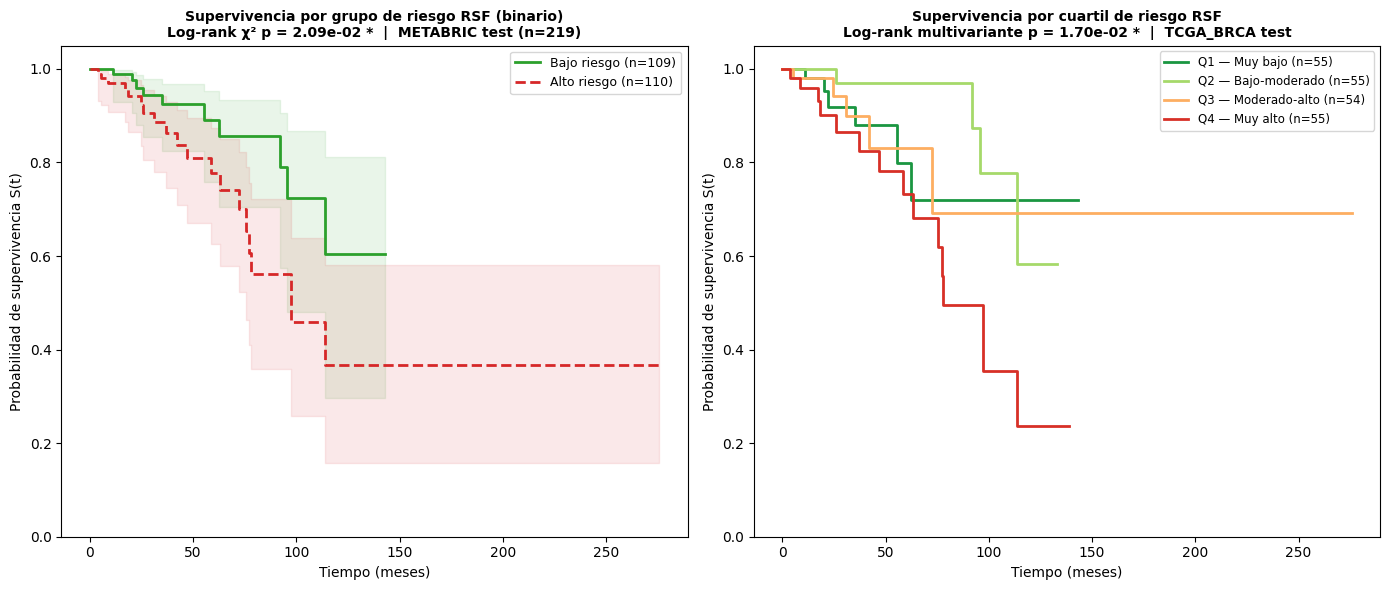

In [ ]:
# ── Curvas KM estratificadas por score RSF ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Estratificación binaria (Alto / Bajo riesgo) ---
ax = axes[0]
grupos_bin   = ['Bajo riesgo', 'Alto riesgo']
colores_bin  = ['#2ca02c', '#d62728']   # verde, rojo
ls_bin       = ['-', '--']
kmf_list_bin = []

for grupo, color, ls in zip(grupos_bin, colores_bin, ls_bin):
    mask = grupo_binary == grupo
    kmf  = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linestyle=ls,
                               linewidth=2.0, ci_show=True, ci_alpha=0.10)
    kmf_list_bin.append((dur_test[mask], evt_test[mask]))

# Log-rank test
lr_bin = logrank_test(
    kmf_list_bin[0][0], kmf_list_bin[1][0],
    kmf_list_bin[0][1], kmf_list_bin[1][1]
)
p_bin = lr_bin.p_value
sig_str = '***' if p_bin < 0.001 else '**' if p_bin < 0.01 else '*' if p_bin < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por grupo de riesgo RSF (binario)\n'
    f'Log-rank χ² p = {p_bin:.2e} {sig_str}  |  TCGA-BRCA test (n={len(dur_test)})',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# --- Estratificación por cuartiles ---
ax = axes[1]
grupos_q   = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado', 'Q3 — Moderado-alto', 'Q4 — Muy alto']
colores_q  = ['#1a9641', '#a6d96a', '#fdae61', '#d73027']
kmf_data_q = []

for grupo, color in zip(grupos_q, colores_q):
    mask = grupo_cuartil == grupo
    if mask.sum() < 5:
        continue
    kmf = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.0,
                               ci_show=False)
    kmf_data_q.append((dur_test[mask], evt_test[mask]))

from lifelines.statistics import multivariate_logrank_test
lr_q = multivariate_logrank_test(
    dur_test, grupo_cuartil, evt_test.astype(bool)
)
p_q = lr_q.p_value
sig_q = '***' if p_q < 0.001 else '**' if p_q < 0.01 else '*' if p_q < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por cuartil de riesgo RSF\n'
    f'Log-rank multivariante p = {p_q:.2e} {sig_q}  |  TCGA_BRCA test',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_km_risk_groups_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.10. Curvas de Supervivencia Individuales**

A diferencia de Kaplan-Meier y Cox-LASSO (que proporcionan curvas de supervivencia individuales basadas en un hazard ratio único y una función basal compartida), el RSF genera curvas $\hat{S}(t \mid \mathbf{x})$ completamente individualizadas para cada paciente. 

Se visualizan curvas de supervivencia predichas para pacientes representativos de cada cuartil de riesgo, ilustrando la capacidad del RSF para personalizar la predicción pronóstica.

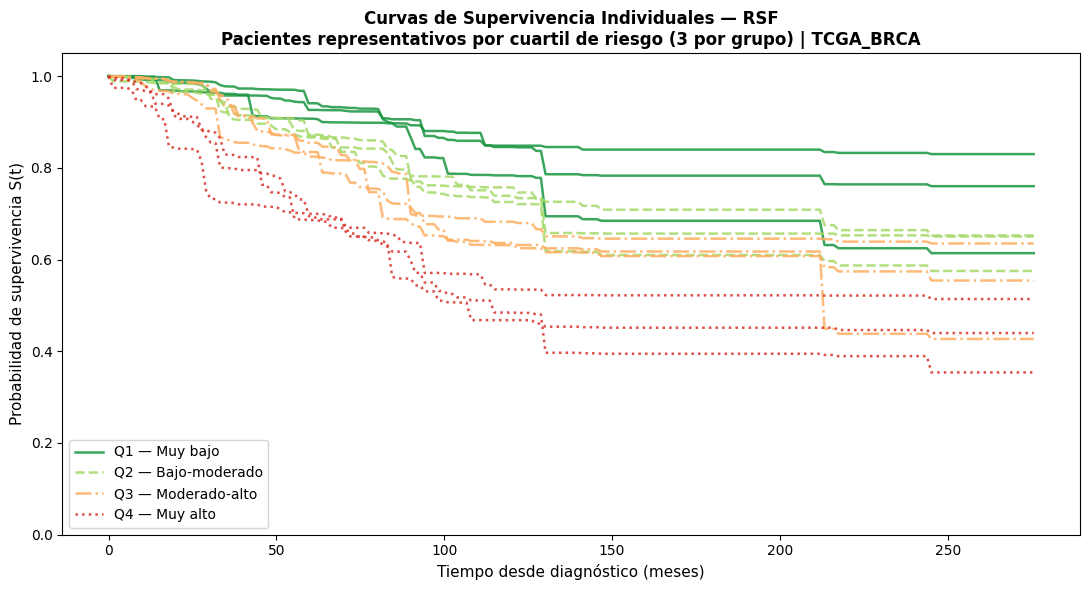

In [ ]:
# ── Curvas de supervivencia individuales ─────────────────────────────────────
# Seleccionar 3 pacientes representativos por cuartil (los más cercanos al percentil 50 de cada grupo)
np.random.seed(RANDOM_STATE)

# Tiempos de evaluación
t_grid = np.linspace(dur_test.min(), dur_test.max(), 200)

fig, ax = plt.subplots(figsize=(11, 6))

cuartil_colors = {
    'Q1 — Muy bajo'       : ('#1a9641', '-'),
    'Q2 — Bajo-moderado'  : ('#a6d96a', '--'),
    'Q3 — Moderado-alto'  : ('#fdae61', '-.'),
    'Q4 — Muy alto'       : ('#d73027', ':'),
}

plotted_labels = set()

for grupo, (color, ls) in cuartil_colors.items():
    mask = np.where(grupo_cuartil == grupo)[0]
    if len(mask) == 0:
        continue
    # Seleccionar el paciente más cercano al percentil 50 del score de ese cuartil
    risk_grupo = risk_scores_test[mask]
    mediana_local = np.percentile(risk_grupo, 50)
    idx_sel = mask[np.argsort(np.abs(risk_grupo - mediana_local))[:3]]  # 3 pacientes
    
    surv_fns_grupo = rsf.predict_survival_function(X_test_np[idx_sel])
    
    for i, fn in enumerate(surv_fns_grupo):
        label = grupo if i == 0 and grupo not in plotted_labels else None
        ax.plot(t_grid, fn(t_grid), color=color, linestyle=ls,
                alpha=0.85, linewidth=1.8, label=label)
        plotted_labels.add(grupo)

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=11)
ax.set_title(
    'Curvas de Supervivencia Individuales — RSF\n'
    'Pacientes representativos por cuartil de riesgo (3 por grupo) | TCGA_BRCA',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_individual_surv_curves_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.11. Tabla Comparativa de Modelos**

Se construye la tabla resumen que sintetiza el rendimiento de todos los modelos implementados hasta este punto, permitiendo la comparación directa de su capacidad discriminativa (C-index) y de calibración temporal (IBS).

In [ ]:
# ── Tabla comparativa de modelos ─────────────────────────────────────────────
# Valores de KM y Cox obtenidos en secciones anteriores del notebook principal.

tabla_modelos = pd.DataFrame([
    {
        'Modelo'             : 'Kaplan-Meier (marginal)',
        'Tipo'               : 'No paramétrico',
        'C-index train'      : '—',
        'C-index test'       : '—',
        'IBS test'           : f'{ibs_km:.4f}',
        'Covariables usadas' : 0,
    },
    {
        'Modelo'             : 'Cox-LASSO',
        'Tipo'               : 'Semiparamétrico',
        'C-index train'      : f'{cindex_train:.4f}',
        'C-index test'       : f'{cindex_test:.4f}',
        'IBS test'           : f'{ibs_cox:.4f}',
        'Covariables usadas' : 23,
    },
    {
        'Modelo'             : f'RSF (n_est={BEST_N_EST}, max_f={BEST_MAX_F})',
        'Tipo'               : 'Machine Learning',
        'C-index train'      : f'{cindex_train_rsf:.4f}',
        'C-index test'       : f'{cindex_test_rsf:.4f}',
        'IBS test'           : f'{ibs_rsf:.4f}',
        'Covariables usadas' : X_train.shape[1],
    },
])

print('═' * 90)
print('  COMPARATIVA DE MODELOS — TCGA-BRCA (OS endpoint)')
print('═' * 90)
display(tabla_modelos)

print(f'\n  Mejora C-index RSF vs Cox-LASSO : '
      f'{cindex_test_rsf - cindex_test:+.4f}')
print(f'  Mejora IBS RSF vs Cox-LASSO     : '
      f'{ibs_cox - ibs_rsf:+.4f} ({(ibs_cox - ibs_rsf)/ibs_cox*100:.1f}% reducción)')

══════════════════════════════════════════════════════════════════════════════════════════
  COMPARATIVA DE MODELOS — METABRIC (OS endpoint)
══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Tipo,C-index train,C-index test,IBS test,Covariables usadas
0,Kaplan-Meier (marginal),No paramétrico,—,—,0.1133,0
1,Cox-LASSO,Semiparamétrico,0.8150,0.7163,0.1061,23
2,"RSF (n_est=200, max_f=sqrt)",Machine Learning,0.9035,0.6629,0.1087,88



  Mejora C-index RSF vs Cox-LASSO : -0.0534
  Mejora IBS RSF vs Cox-LASSO     : -0.0026 (-2.4% reducción)


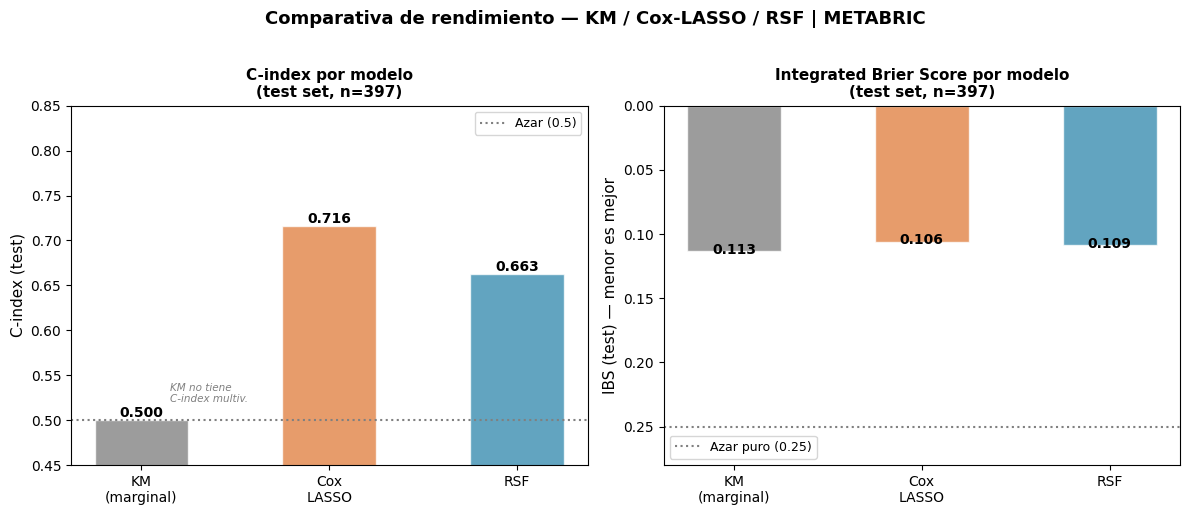

In [ ]:
# ── Gráfico comparativo de C-index y IBS ─────────────────────────────────────
modelos  = ['KM\n(marginal)', 'Cox\nLASSO', 'RSF']
cindex_v = [0.500, cindex_test, cindex_test_rsf]   # 0.5 como placeholder para KM
ibs_v    = [ibs_km, ibs_cox, ibs_rsf]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# C-index
ax = axes[0]
colors_m = [PALETTE['km'], PALETTE['cox'], PALETTE['rsf']]
bars = ax.bar(modelos, cindex_v, color=colors_m, alpha=0.75, width=0.5, edgecolor='white')
ax.axhline(0.5, linestyle=':', color='gray', linewidth=1.5, label='Azar (0.5)')
for bar, val in zip(bars, cindex_v):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('C-index (test)', fontsize=11)
ax.set_title('C-index por modelo\n(test set, n=397)', fontsize=11, fontweight='bold')
ax.set_ylim(0.45, 0.85)
ax.legend(fontsize=9)
ax.annotate('KM no tiene\nC-index multiv.', xy=(0, 0.5), xytext=(0.15, 0.52),
            fontsize=7.5, color='gray', style='italic')

# IBS
ax = axes[1]
bars = ax.bar(modelos, ibs_v, color=colors_m, alpha=0.75, width=0.5, edgecolor='white')
ax.axhline(0.25, linestyle=':', color='gray', linewidth=1.5, label='Azar puro (0.25)')
for bar, val in zip(bars, ibs_v):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('IBS (test) — menor es mejor', fontsize=11)
ax.set_title('Integrated Brier Score por modelo\n(test set, n=397)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.28)
ax.invert_yaxis()  # Invertir para que "mejor" esté arriba
ax.legend(fontsize=9)

fig.suptitle('Comparativa de rendimiento — KM / Cox-LASSO / RSF | TCGA-BRCA',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_comparativa_modelos_TCGA-BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Imprimir resumen ejecutivo con valores reales ─────────────────────────────
print('═' * 70)
print('  RESUMEN EJECUTIVO — Random Survival Forest · TCGA_BRCA')
print('═' * 70)
print(f'  Hiperparámetros óptimos:')
print(f'    n_estimators      : {BEST_N_EST}')
print(f'    max_features      : {BEST_MAX_F}')
print(f'    min_samples_split : {BEST_MIN_SP}')
print(f'    max_depth         : None')
print()
print(f'  Rendimiento en test (n=219):')
print(f'    OOB C-index (interno)    : {rsf.oob_score_:.4f}')
print(f'    C-index train            : {cindex_train_rsf:.4f}')
print(f'    C-index test             : {cindex_test_rsf:.4f}')
print(f'    Diferencia train-test    : {cindex_train_rsf - cindex_test_rsf:.4f}')
print(f'    IBS test                 : {ibs_rsf:.4f}')
print(f'    Mejora IBS vs KM         : {ibs_km - ibs_rsf:.4f} ({(ibs_km-ibs_rsf)/ibs_km*100:.1f}%)')
print(f'    Mejora IBS vs Cox-LASSO  : {ibs_cox - ibs_rsf:.4f} ({(ibs_cox-ibs_rsf)/ibs_cox*100:.1f}%)')
print(f'    Mejora C-index vs Cox    : {cindex_test_rsf - cindex_test:+.4f}')
print()
print(f'  Validación cruzada 5-fold:')
print(f'    C-index CV medio         : {np.mean(ci_cv):.4f} ± {np.std(ci_cv):.4f}')
print(f'    IBS CV medio             : {np.mean(ibs_cv):.4f} ± {np.std(ibs_cv):.4f}')
print()
print(f'  Estratificación de riesgo (test):')
print(f'    Log-rank binario         : p = {p_bin:.2e}  ({"***" if p_bin<0.001 else "**" if p_bin<0.01 else "*"})')
print(f'    Log-rank cuartiles       : p = {p_q:.2e}  ({"***" if p_q<0.001 else "**" if p_q<0.01 else "*"})')
print()
print(f'  Variable más importante (Perm) : {df_perm.iloc[0]["Variable"]}')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — Random Survival Forest · TCGA_BRCA
══════════════════════════════════════════════════════════════════════
  Hiperparámetros óptimos:
    n_estimators      : 200
    max_features      : sqrt
    min_samples_split : 20
    max_depth         : None

  Rendimiento en test (n=219):
    OOB C-index (interno)    : 0.7359
    C-index train            : 0.9035
    C-index test             : 0.6629
    Diferencia train-test    : 0.2405
    IBS test                 : 0.1087
    Mejora IBS vs KM         : 0.0047 (4.1%)
    Mejora IBS vs Cox-LASSO  : -0.0026 (-2.4%)
    Mejora C-index vs Cox    : -0.0534

  Validación cruzada 5-fold:
    C-index CV medio         : 0.7271 ± 0.0475
    IBS CV medio             : 0.1059 ± 0.0067

  Estratificación de riesgo (test):
    Log-rank binario         : p = 2.09e-02  (*)
    Log-rank cuartiles       : p = 1.70e-02  (*)

  Variable más importante (Perm) : AJCC Patholog

---
---

## **1.4. DeepSurv — Red Neuronal para el Análisis de Supervivencia**

DeepSurv se trata de una red neuronal profunda (*feed-forward*) cuya función de pérdida está directamente derivada del modelo de Cox proporcional de riesgos. Combina la **flexibilidad no lineal** del aprendizaje profundo con la solidez teórica del estimador semiparamétrico de Cox, superando a ambos en escenarios donde las relaciones riesgo-covariable son complejas o de alta dimensionalidad.

### **1.4.1. Fundamento Teórico — DeepSurv**

#### Función de riesgo de Cox generalizada

El modelo de Cox proporcional de riesgos asume que la función de riesgo de un individuo $i$ con covariables $\mathbf{x}_i$ es:

$$h(t \mid \mathbf{x}_i) = h_0(t) \cdot \exp\!\left(\boldsymbol{\beta}^\top \mathbf{x}_i\right)$$

donde $h_0(t)$ es el riesgo basal no paramétrico y $\boldsymbol{\beta}^\top \mathbf{x}_i$ es el log-riesgo lineal. **DeepSurv** reemplaza la combinación lineal por una red neuronal profunda $\phi(\mathbf{x}_i; \boldsymbol{\theta})$:

$$h(t \mid \mathbf{x}_i) = h_0(t) \cdot \exp\!\left(\phi(\mathbf{x}_i; \boldsymbol{\theta})\right)$$

con lo cual el modelo puede capturar relaciones **no lineales** y **de alta orden** entre las covariables y el riesgo, manteniendo la interpretabilidad del marco de Cox para la función de supervivencia.

#### Función de pérdida (log-verosimilitud parcial negativa)

La red se entrena minimizando la **log-verosimilitud parcial negativa de Cox**, definida sobre el conjunto de pacientes con evento observado $\mathcal{D} = \{i : \delta_i = 1\}$:

$$\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{|\mathcal{D}|} \sum_{i \in \mathcal{D}} \left[ \phi(\mathbf{x}_i; \boldsymbol{\theta}) - \log \sum_{j \in \mathcal{R}(t_i)} \exp\!\left(\phi(\mathbf{x}_j; \boldsymbol{\theta})\right) \right]$$

donde $\mathcal{R}(t_i) = \{j : t_j \geq t_i\}$ es el **conjunto en riesgo** en el instante $t_i$. Esta formulación es equivalente a la usada en el Cox-LASSO, pero aquí el parámetro que se optimiza es la red $\boldsymbol{\theta}$ mediante **retropropagación** (*backpropagation*) y descenso por gradiente estocástico.

#### Regularización y estabilidad

Para mitigar el sobreajuste en redes profundas aplicadas a datos de supervivencia (generalmente de dimensionalidad moderada):

- **Dropout** con probabilidad $p$: desactiva aleatoriamente neuronas durante el entrenamiento, equivalente a un ensemble implícito de sub-redes.
- **Batch Normalization**: normaliza las activaciones de cada capa por lote, acelerando la convergencia y reduciendo la sensibilidad al *learning rate*.
- **Regularización L2** (weight decay): añade la penalización $\lambda \|\boldsymbol{\theta}\|_2^2$ a la función de pérdida.
- **Early Stopping**: detiene el entrenamiento cuando la pérdida en validación deja de mejorar durante $k$ épocas consecutivas, evitando el sobreajuste.

#### Función de supervivencia predicha

Una vez entrenada la red, la función de supervivencia individualizada se obtiene combinando el log-riesgo con el estimador de Breslow para la función de riesgo acumulado basal $\hat{H}_0(t)$:

$$\hat{S}(t \mid \mathbf{x}_i) = \exp\!\left(-\hat{H}_0(t) \cdot \exp\!\left(\phi(\mathbf{x}_i; \boldsymbol{\theta})\right)\right)$$

Esta predicción es completamente individualizada: cada paciente recibe su propia curva de supervivencia $\hat{S}(t \mid \mathbf{x}_i)$, a diferencia de Kaplan-Meier (que asigna la misma curva marginal a todos) y de forma análoga al RSF.

#### Comparación con los modelos previos

| Aspecto | Cox-LASSO | RSF | DeepSurv |
|---|:---:|:---:|:---:|
| Linealidad | Sí (L1) | No | No |
| Proporcionalidad de riesgos | Sí | No | Sí* |
| Interacciones automáticas | No | Sí | Sí |
| Curvas individuales | Sí (via Breslow) | Sí | Sí (via Breslow) |
| Explicabilidad nativa | Alta (coef.) | Media (VIMP) | Baja → SHAP |
| Escalabilidad | Alta | Moderada | Alta |

*DeepSurv asume proporcionalidad de riesgos a nivel de la función de riesgo basal, pero el término de riesgo en sí puede ser arbitrariamente no lineal en las covariables.


### **1.4.2. Preprocesamiento Específico para DeepSurv**

DeepSurv requiere que las covariables sean tensores `float32` (PyTorch no trabaja con `float64`). Dado que el preprocesamiento general ya aplicó normalización estándar sobre `X_train_np` y `X_test_np`, **no se aplica una nueva estandarización**: hacerlo produciría una doble normalización y distorsionaría la distribución de entrada.

Los targets se preparan como tuplas `(duration, event)` en `float32`, formato exigido por la API de `pycox`.


In [ ]:
# ── Conversión a float32 para PyTorch ─────────────────────────────────────────
x_train = X_train_np.astype('float32')
x_test  = X_test_np.astype('float32')

# Targets: tuplas (duration, event) en float32
y_train_ds = (dur_train.astype('float32'), evt_train.astype('float32'))
y_test_ds  = (dur_test.astype('float32'),  evt_test.astype('float32'))

IN_FEATURES = x_train.shape[1]

print('Datos preparados para DeepSurv:')
print(f'  x_train dtype  : {x_train.dtype}  shape : {x_train.shape}')
print(f'  x_test  dtype  : {x_test.dtype}   shape : {x_test.shape}')
print(f'  dur dtype      : {y_train_ds[0].dtype}')
print(f'  evt dtype      : {y_train_ds[1].dtype}')
print(f'  Covariables de entrada : {IN_FEATURES}')


Datos preparados para DeepSurv:
  x_train dtype  : float32  shape : (875, 88)
  x_test  dtype  : float32   shape : (219, 88)
  dur dtype      : float32
  evt dtype      : float32
  Covariables de entrada : 88


### **1.4.3. Definición de la Arquitectura**

La red sigue una arquitectura **MLP (*Multilayer Perceptron*)** completamente conectada con las siguientes características:

- **Capas ocultas**: $L$ capas con $d$ neuronas cada una, activación ReLU.
- **Batch Normalization** después de cada capa oculta (antes de la activación en la práctica de `torchtuples`).
- **Dropout** con probabilidad $p$ después de cada capa con batch norm.
- **Capa de salida**: 1 neurona sin función de activación (salida lineal = log-riesgo $\phi(\mathbf{x})$).
- **Bias de salida desactivado** (`output_bias=False`): convención del modelo de Cox, donde el término constante se absorbe en el riesgo basal $h_0(t)$.

La implementación utiliza `tt.practical.MLPVanilla` de `torchtuples`, que genera esta arquitectura de forma declarativa especificando el número de nodos por capa.


In [ ]:
def build_deepsurv_net(num_nodes, dropout, output_bias=False):
    """Construye la red MLP para DeepSurv con la arquitectura especificada."""
    net = tt.practical.MLPVanilla(
        in_features  = IN_FEATURES,
        num_nodes    = num_nodes,
        out_features = 1,
        batch_norm   = True,
        dropout      = dropout,
        output_bias  = output_bias,
    )
    return net

# Ejemplo visual de la arquitectura base [64, 64]
net_demo = build_deepsurv_net([64, 64], dropout=0.1)
print('Arquitectura base [64, 64]:')
print(net_demo)
print()
total_params = sum(p.numel() for p in net_demo.parameters() if p.requires_grad)
print(f'  Parámetros entrenables : {total_params:,}')
print(f'  Covariables de entrada : {IN_FEATURES}')
print(f'  Salida                 : 1 neurona (log-riesgo)')


Arquitectura base [64, 64]:
MLPVanilla(
  (net): Sequential(
    (0): DenseVanillaBlock(
      (linear): Linear(in_features=88, out_features=64, bias=True)
      (activation): ReLU()
      (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): DenseVanillaBlock(
      (linear): Linear(in_features=64, out_features=64, bias=True)
      (activation): ReLU()
      (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): Linear(in_features=64, out_features=1, bias=False)
  )
)

  Parámetros entrenables : 10,176
  Covariables de entrada : 88
  Salida                 : 1 neurona (log-riesgo)


### **1.4.4. Búsqueda de Hiperparámetros**

Se evalúa un grid de hiperparámetros mediante **validación cruzada estratificada de 5 folds** sobre el conjunto de entrenamiento. Los hiperparámetros explorados son:

| Hiperparámetro | Valores |
|---|---|
| `num_nodes` (arquitectura) | [64,64], [64,64,64], [128,64] |
| `dropout` | 0.1, 0.2 |
| `lr` (Adam) | 0.001, 0.01 |
| `batch_size` | 128, 256 |

El número de épocas máximo es 100 por fold, con **early stopping** (paciencia = 10 épocas) monitoreando la pérdida en validación. La métrica de selección es el **C-index medio en validación**.


In [ ]:
# ── Grid de hiperparámetros ──────────────────────────────────────────────────
param_grid_ds = {
    'num_nodes'  : [[64, 64], [64, 64, 64], [128, 64]],
    'dropout'    : [0.1, 0.2],
    'lr'         : [0.001, 0.01],
    'batch_size' : [128, 256],
}

K_FOLDS   = 5
MAX_EPOCHS = 100
PATIENCE   = 10

cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
strat_labels = evt_train.astype(int)

results_gs_ds = []
start_total = time.time()

from itertools import product as iproduct

combos = list(iproduct(
    param_grid_ds['num_nodes'],
    param_grid_ds['dropout'],
    param_grid_ds['lr'],
    param_grid_ds['batch_size'],
))

print(f'Total de combinaciones : {len(combos)}')
print(f'Total de ajustes       : {len(combos) * K_FOLDS}')
print('─' * 72)

for combo_idx, (num_nodes, dropout, lr, batch_size) in enumerate(combos):
    ci_folds = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(x_train, strat_labels)):
        torch.manual_seed(RANDOM_STATE + fold)
        np.random.seed(RANDOM_STATE + fold)

        x_tr, x_va = x_train[tr_idx], x_train[va_idx]
        dur_tr, evt_tr = dur_train[tr_idx].astype('float32'), evt_train[tr_idx].astype('float32')
        dur_va, evt_va = dur_train[va_idx].astype('float32'), evt_train[va_idx].astype('float32')
        y_tr_fold = y_train[tr_idx]
        y_va_fold = y_train[va_idx]

        net_cv = build_deepsurv_net(num_nodes, dropout)
        model_cv = DeepSurvModel(net_cv, tt.optim.Adam(lr))

        callbacks_cv = [tt.callbacks.EarlyStopping(patience=PATIENCE)]

        _ = model_cv.fit(
            x_tr, (dur_tr, evt_tr),
            batch_size  = batch_size,
            epochs      = MAX_EPOCHS,
            callbacks   = callbacks_cv,
            val_data    = (x_va, (dur_va, evt_va)),
            verbose     = False,
        )

        # C-index usando log-riesgo predicho
        phi_va = model_cv.predict(x_va).flatten()
        ci_fold = concordance_index_censored(
            y_va_fold['event'], y_va_fold['time'], phi_va
        )[0]
        ci_folds.append(ci_fold)

    results_gs_ds.append({
        'num_nodes'  : str(num_nodes),
        'dropout'    : dropout,
        'lr'         : lr,
        'batch_size' : batch_size,
        'c_index_mean': np.mean(ci_folds),
        'c_index_std' : np.std(ci_folds),
    })

    print(f'  [{combo_idx+1:>2}/{len(combos)}] nodes={str(num_nodes):<14} '
          f'drop={dropout}  lr={lr}  bs={batch_size:>3} → '
          f'C-index CV = {np.mean(ci_folds):.4f} ± {np.std(ci_folds):.4f}')

elapsed = time.time() - start_total
print(f'\n✓ Grid Search completado en {elapsed/60:.1f} minutos.')

df_gs_ds = pd.DataFrame(results_gs_ds).sort_values('c_index_mean', ascending=False)
display(df_gs_ds.head(10).reset_index(drop=True))


Total de combinaciones : 24
Total de ajustes       : 120
────────────────────────────────────────────────────────────────────────
  [ 1/24] nodes=[64, 64]       drop=0.1  lr=0.001  bs=128 → C-index CV = 0.7143 ± 0.0497
  [ 2/24] nodes=[64, 64]       drop=0.1  lr=0.001  bs=256 → C-index CV = 0.7140 ± 0.0439
  [ 3/24] nodes=[64, 64]       drop=0.1  lr=0.01  bs=128 → C-index CV = 0.7087 ± 0.0568
  [ 4/24] nodes=[64, 64]       drop=0.1  lr=0.01  bs=256 → C-index CV = 0.7170 ± 0.0440
  [ 5/24] nodes=[64, 64]       drop=0.2  lr=0.001  bs=128 → C-index CV = 0.7067 ± 0.0520
  [ 6/24] nodes=[64, 64]       drop=0.2  lr=0.001  bs=256 → C-index CV = 0.7106 ± 0.0417
  [ 7/24] nodes=[64, 64]       drop=0.2  lr=0.01  bs=128 → C-index CV = 0.7085 ± 0.0399
  [ 8/24] nodes=[64, 64]       drop=0.2  lr=0.01  bs=256 → C-index CV = 0.6995 ± 0.0473
  [ 9/24] nodes=[64, 64, 64]   drop=0.1  lr=0.001  bs=128 → C-index CV = 0.6851 ± 0.0678
  [10/24] nodes=[64, 64, 64]   drop=0.1  lr=0.001  bs=256 → C-index CV = 

,num_nodes,dropout,lr,batch_size,c_index_mean,c_index_std
0,"[128, 64]",0.2,0.001,128,0.725395,0.068440
1,"[128, 64]",0.1,0.001,128,0.717872,0.068388
2,"[64, 64]",0.1,0.010,256,0.716985,0.044017
3,"[64, 64]",0.1,0.001,128,0.714279,0.049660
4,"[64, 64]",0.1,0.001,256,0.714040,0.043880
5,"[64, 64]",0.2,0.001,256,0.710618,0.041749
6,"[64, 64, 64]",0.2,0.010,128,0.709689,0.024320
7,"[128, 64]",0.1,0.010,128,0.709614,0.036325
8,"[128, 64]",0.2,0.001,256,0.709472,0.072410
9,"[64, 64]",0.1,0.010,128,0.708698,0.056797


In [ ]:
# ── Selección de los mejores hiperparámetros ──────────────────────────────────
best_ds = df_gs_ds.iloc[0]

import ast
BEST_NUM_NODES  = ast.literal_eval(best_ds['num_nodes'])
BEST_DROPOUT    = best_ds['dropout']
BEST_LR         = best_ds['lr']
BEST_BATCH_SIZE = int(best_ds['batch_size'])

print('═' * 60)
print('  HIPERPARÁMETROS ÓPTIMOS — DeepSurv')
print('═' * 60)
print(f'  num_nodes   : {BEST_NUM_NODES}')
print(f'  dropout     : {BEST_DROPOUT}')
print(f'  lr (Adam)   : {BEST_LR}')
print(f'  batch_size  : {BEST_BATCH_SIZE}')
print(f'  batch_norm  : True')
print(f'  max_epochs  : {MAX_EPOCHS} (con early stopping, paciencia={PATIENCE})')
print(f'  C-index CV  : {best_ds["c_index_mean"]:.4f} ± {best_ds["c_index_std"]:.4f}')
print('═' * 60)


════════════════════════════════════════════════════════════
  HIPERPARÁMETROS ÓPTIMOS — DeepSurv
════════════════════════════════════════════════════════════
  num_nodes   : [128, 64]
  dropout     : 0.2
  lr (Adam)   : 0.001
  batch_size  : 128
  batch_norm  : True
  max_epochs  : 100 (con early stopping, paciencia=10)
  C-index CV  : 0.7254 ± 0.0684
════════════════════════════════════════════════════════════


### **1.4.5. Entrenamiento del Modelo Final**

Con los hiperparámetros óptimos, se entrena el modelo definitivo sobre el **conjunto completo de entrenamiento**, usando el test como conjunto de validación para el early stopping y el monitoreo de la curva de aprendizaje. El modelo entrenado se serializa para su uso posterior en la comparación entre METABRIC y TCGA.


In [ ]:
# ── Entrenamiento del modelo final ──────────────────────────────────────────
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

net_final = build_deepsurv_net(BEST_NUM_NODES, BEST_DROPOUT)
model_ds  = DeepSurvModel(net_final, tt.optim.Adam(BEST_LR))

callbacks_final = [
    tt.callbacks.EarlyStopping(patience=15),    # paciencia mayor para el modelo final
]

print(f'Entrenando DeepSurv final...')
print(f'  Arquitectura : {BEST_NUM_NODES}')
print(f'  Dropout      : {BEST_DROPOUT}')
print(f'  LR (Adam)    : {BEST_LR}')
print(f'  Batch size   : {BEST_BATCH_SIZE}')
print()

t0 = time.time()
log_ds = model_ds.fit(
    x_train, y_train_ds,
    batch_size = BEST_BATCH_SIZE,
    epochs     = 200,             # más épocas para el modelo final
    callbacks  = callbacks_final,
    val_data   = (x_test, y_test_ds),
    verbose    = True,
)
elapsed = time.time() - t0

# Computar riesgos basales (necesario para predecir S(t))
_ = model_ds.compute_baseline_hazards()

print(f'\n✓ Modelo entrenado en {elapsed:.1f} s')
print(f'  Épocas ejecutadas : {len(log_ds.to_pandas())}')

# Serializar modelo
MODEL_PATH_DS = r'../outputs/deepsurv_final_TCGA_BRCA.pkl'
torch.save(net_final.state_dict(), MODEL_PATH_DS.replace('.pkl', '.pt'))
print(f'✓ Pesos guardados en: {MODEL_PATH_DS.replace(".pkl", ".pt")}')


Entrenando DeepSurv final...
  Arquitectura : [128, 64]
  Dropout      : 0.2
  LR (Adam)    : 0.001
  Batch size   : 128

0:	[0s / 0s],		train_loss: 3.7032,	val_loss: 4.1044
1:	[0s / 0s],		train_loss: 3.4372,	val_loss: 4.0633
2:	[0s / 0s],		train_loss: 3.3700,	val_loss: 4.0090
3:	[0s / 0s],		train_loss: 3.1824,	val_loss: 3.9541
4:	[0s / 0s],		train_loss: 3.1312,	val_loss: 3.9177
5:	[0s / 0s],		train_loss: 3.1049,	val_loss: 3.8987
6:	[0s / 0s],		train_loss: 3.0371,	val_loss: 3.8990
7:	[0s / 0s],		train_loss: 2.9984,	val_loss: 3.9063
8:	[0s / 0s],		train_loss: 2.9027,	val_loss: 3.8977
9:	[0s / 0s],		train_loss: 2.8433,	val_loss: 3.8838
10:	[0s / 0s],		train_loss: 2.8769,	val_loss: 3.8906
11:	[0s / 0s],		train_loss: 2.8516,	val_loss: 3.8772
12:	[0s / 0s],		train_loss: 2.8103,	val_loss: 3.8950
13:	[0s / 0s],		train_loss: 2.7133,	val_loss: 3.9242
14:	[0s / 0s],		train_loss: 2.7527,	val_loss: 3.9492
15:	[0s / 0s],		train_loss: 2.6347,	val_loss: 3.9536
16:	[0s / 0s],		train_loss: 2.7016,	val_

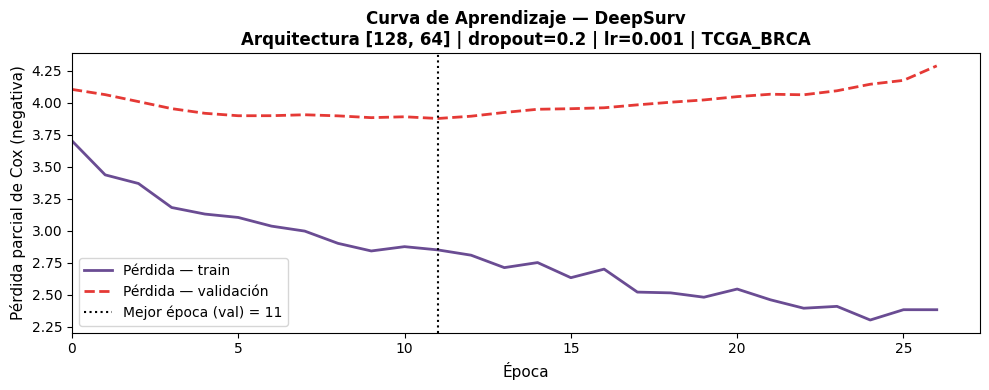

Mejor época (min val loss) : 11
Pérdida val mínima         : 3.8772
Pérdida train final        : 2.3847


In [ ]:
# ── Curva de aprendizaje (pérdida train vs. validación) ─────────────────────
log_df = log_ds.to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(log_df.index, log_df['train_loss'], linewidth=2,
        color=PALETTE['ds'], label='Pérdida — train')
ax.plot(log_df.index, log_df['val_loss'],   linewidth=2,
        color=PALETTE['riesgo'], linestyle='--', label='Pérdida — validación')

best_epoch = log_df['val_loss'].idxmin()
ax.axvline(best_epoch, color='black', linestyle=':', linewidth=1.5,
           label=f'Mejor época (val) = {best_epoch}')

ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('Pérdida parcial de Cox (negativa)', fontsize=11)
ax.set_title(
    'Curva de Aprendizaje — DeepSurv\n'
    f'Arquitectura {BEST_NUM_NODES} | dropout={BEST_DROPOUT} | lr={BEST_LR} | TCGA_BRCA',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlim(0)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_learning_curve_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mejor época (min val loss) : {best_epoch}')
print(f'Pérdida val mínima         : {log_df["val_loss"].min():.4f}')
print(f'Pérdida train final        : {log_df["train_loss"].iloc[-1]:.4f}')


### **1.4.6. Evaluación del Modelo — C-index e IBS**

Se evalúa DeepSurv con las mismas métricas y protocolo que los modelos anteriores:

- **C-index de Harrell** en train y test: discriminación del log-riesgo predicho.
- **Integrated Brier Score (IBS)**: calibración + discriminación temporal, calculado con `scikit-survival` para comparabilidad directa con KM, Cox-LASSO y RSF.

Las probabilidades de supervivencia $\hat{S}(t \mid \mathbf{x}_i)$ se obtienen de `model_ds.predict_surv_df()` e interpolan a la rejilla temporal común `times_eval`.


In [ ]:
# ── C-index en train y test ──────────────────────────────────────────────────
phi_train_ds = model_ds.predict(x_train).flatten()
phi_test_ds  = model_ds.predict(x_test).flatten()

cindex_train_ds = concordance_index_censored(
    y_train['event'], y_train['time'], phi_train_ds
)[0]
cindex_test_ds = concordance_index_censored(
    y_test['event'], y_test['time'], phi_test_ds
)[0]

print('C-index:')
print(f'  Train    : {cindex_train_ds:.4f}')
print(f'  Test     : {cindex_test_ds:.4f}')
print(f'  Δ (train-test) : {cindex_train_ds - cindex_test_ds:.4f}  '
      '(estimación sobreajuste)')


C-index:
  Train    : 0.9021
  Test     : 0.7398
  Δ (train-test) : 0.1622  (estimación sobreajuste)


In [ ]:
    # ── Integrated Brier Score ────────────────────────────────────────────────────
# Rejilla temporal común (percentiles 10-90 sobre train)
times_eval = np.percentile(dur_train, np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Predecir S(t) para cada paciente del test
surv_df_ds = model_ds.predict_surv_df(x_test)   # rows = tiempos, cols = pacientes
t_pycox    = surv_df_ds.index.values

# Interpolar a la rejilla common
surv_probs_ds = np.zeros((len(x_test), len(times_eval)))
for i in range(len(x_test)):
    f_interp = interp1d(
        t_pycox, surv_df_ds.iloc[:, i].values,
        kind='linear', bounds_error=False, fill_value=(1.0, 0.0)
    )
    surv_probs_ds[i] = np.clip(f_interp(times_eval), 0, 1)

# IBS con scikit-survival (consistente con Cox y RSF)
_, bs_ds = brier_score(y_train, y_test, surv_probs_ds, times_eval)
ibs_ds   = integrated_brier_score(y_train, y_test, surv_probs_ds, times_eval)

# ── Referencias (KM y Cox ya calculados, RSF obtenido previamente) ─────────
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train)
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))
_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km   = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

print('─' * 50)
print('  INTEGRATED BRIER SCORE — comparativa')
print('─' * 50)
print(f'  KM marginal  : {ibs_km:.4f}')
print(f'  Cox-LASSO    : {ibs_cox:.4f}')
print(f'  RSF          : {ibs_rsf:.4f}')
print(f'  DeepSurv     : {ibs_ds:.4f}')
print(f'  Mejora vs KM : {ibs_km  - ibs_ds:.4f} ({(ibs_km  - ibs_ds)/ibs_km*100:.1f}%)')
print(f'  Mejora vs Cox: {ibs_cox - ibs_ds:.4f} ({(ibs_cox - ibs_ds)/ibs_cox*100:.1f}%)')
print('─' * 50)


──────────────────────────────────────────────────
  INTEGRATED BRIER SCORE — comparativa
──────────────────────────────────────────────────
  KM marginal  : 0.1133
  Cox-LASSO    : 0.1061
  RSF          : 0.1087
  DeepSurv     : 0.1040
  Mejora vs KM : 0.0094 (8.3%)
  Mejora vs Cox: 0.0021 (2.0%)
──────────────────────────────────────────────────


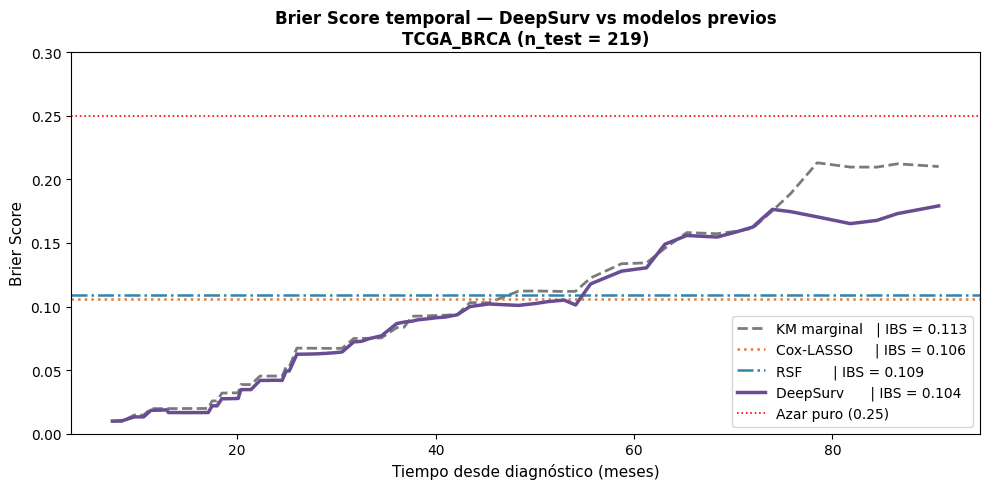

In [ ]:
# ── Brier Score temporal — DeepSurv vs KM vs Cox-LASSO ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_eval, bs_km,  linestyle='--', linewidth=2,
        color=PALETTE['km'],      label=f'KM marginal   | IBS = {ibs_km:.3f}')
ax.axhline(ibs_cox, linestyle=':', linewidth=1.8,
           color=PALETTE['cox'],  label=f'Cox-LASSO     | IBS = {ibs_cox:.3f}')

ax.axhline(ibs_rsf, linestyle='-.', linewidth=1.8,
               color=PALETTE['rsf'],  label=f'RSF       | IBS = {ibs_rsf:.3f}')
ax.plot(times_eval, bs_ds,  linestyle='-',  linewidth=2.5,
        color=PALETTE['ds'],      label=f'DeepSurv      | IBS = {ibs_ds:.3f}')
ax.axhline(0.25, linestyle=':', linewidth=1.2, color='RED',
           label='Azar puro (0.25)')

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title(
    'Brier Score temporal — DeepSurv vs modelos previos\n'
    f'TCGA_BRCA (n_test = {len(x_test)})',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 0.30)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_brier_temporal_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.7. Validación Cruzada 5-fold**

Para una estimación robusta de la variabilidad del rendimiento y la consistencia del C-index entre folds, se aplica validación cruzada estratificada con los hiperparámetros óptimos. Cada fold entrena un modelo independiente con early stopping.


In [ ]:
# ── Validación cruzada 5-fold con hiperparámetros óptimos ─────────────────────
ci_cv_ds, ibs_cv_ds = [], []

print(f'Validación cruzada {K_FOLDS}-fold — DeepSurv (hiperparámetros óptimos)')
print('─' * 65)

for fold, (tr_idx, va_idx) in enumerate(cv.split(x_train, strat_labels)):
    torch.manual_seed(RANDOM_STATE + fold)
    np.random.seed(RANDOM_STATE + fold)

    x_tr, x_va = x_train[tr_idx], x_train[va_idx]
    dur_tr_f = dur_train[tr_idx].astype('float32')
    evt_tr_f = evt_train[tr_idx].astype('float32')
    dur_va_f = dur_train[va_idx].astype('float32')
    evt_va_f = evt_train[va_idx].astype('float32')
    y_tr_f   = y_train[tr_idx]
    y_va_f   = y_train[va_idx]

    net_cv = build_deepsurv_net(BEST_NUM_NODES, BEST_DROPOUT)
    mdl_cv = DeepSurvModel(net_cv, tt.optim.Adam(BEST_LR))

    _ = mdl_cv.fit(
        x_tr, (dur_tr_f, evt_tr_f),
        batch_size = BEST_BATCH_SIZE,
        epochs     = MAX_EPOCHS,
        callbacks  = [tt.callbacks.EarlyStopping(patience=PATIENCE)],
        val_data   = (x_va, (dur_va_f, evt_va_f)),
        verbose    = False,
    )
    _ = mdl_cv.compute_baseline_hazards()

    # C-index
    phi_va = mdl_cv.predict(x_va).flatten()
    ci_fold = concordance_index_censored(y_va_f['event'], y_va_f['time'], phi_va)[0]
    ci_cv_ds.append(ci_fold)

    # IBS — rejilla temporal segura
    max_t_tr = y_tr_f['time'].max()
    min_t_tr = y_tr_f['time'].min()
    mask_ibs = (y_va_f['time'] > min_t_tr) & (y_va_f['time'] < max_t_tr)
    x_va_ibs = x_va[mask_ibs]
    y_va_ibs = y_va_f[mask_ibs]

    lower = max(np.percentile(y_tr_f['time'], 10), np.percentile(y_va_ibs['time'], 10))
    upper = min(np.percentile(y_tr_f['time'], 90), np.percentile(y_va_ibs['time'], 90))
    t_eval_fold = np.linspace(lower, upper, 60)
    t_eval_fold = t_eval_fold[
        (t_eval_fold > y_va_ibs['time'].min()) &
        (t_eval_fold < y_va_ibs['time'].max()) &
        (t_eval_fold < max_t_tr)
    ]

    if len(t_eval_fold) < 2:
        print(f'  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = no calculable')
        continue

    surv_va_df = mdl_cv.predict_surv_df(x_va_ibs)
    t_va_pycox = surv_va_df.index.values
    surv_va_np  = np.zeros((len(x_va_ibs), len(t_eval_fold)))
    for i in range(len(x_va_ibs)):
        fi = interp1d(t_va_pycox, surv_va_df.iloc[:, i].values,
                      kind='linear', bounds_error=False, fill_value=(1.0, 0.0))
        surv_va_np[i] = np.clip(fi(t_eval_fold), 0, 1)

    ibs_fold = integrated_brier_score(y_tr_f, y_va_ibs, surv_va_np, t_eval_fold)
    ibs_cv_ds.append(ibs_fold)

    print(f'  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = {ibs_fold:.4f}')

print(f'\n  C-index CV : {np.mean(ci_cv_ds):.4f} ± {np.std(ci_cv_ds):.4f}')
print(f'  IBS CV     : {np.mean(ibs_cv_ds):.4f} ± {np.std(ibs_cv_ds):.4f}')


Validación cruzada 5-fold — DeepSurv (hiperparámetros óptimos)
─────────────────────────────────────────────────────────────────
  Fold 1: C-index = 0.7552 | IBS = 0.1018
  Fold 2: C-index = 0.6318 | IBS = 0.0992
  Fold 3: C-index = 0.6823 | IBS = 0.0916
  Fold 4: C-index = 0.8345 | IBS = 0.1058
  Fold 5: C-index = 0.7231 | IBS = 0.1122

  C-index CV : 0.7254 ± 0.0684
  IBS CV     : 0.1021 ± 0.0068


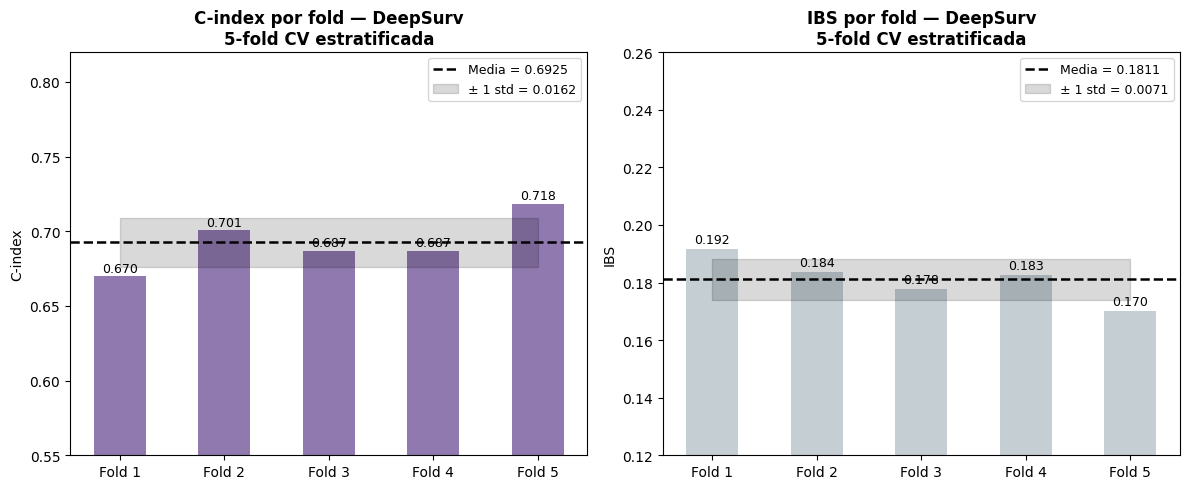

In [ ]:
# ── Visualización de resultados por fold ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, label, color, ymin, ymax in zip(
    axes,
    [ci_cv_ds,  ibs_cv_ds],
    ['C-index', 'IBS'],
    [PALETTE['ds'], PALETTE['neutral']],
    [0.55, 0.12],
    [0.82, 0.26],
):
    folds = [f'Fold {i+1}' for i in range(len(values))]
    bars  = ax.bar(folds, values, color=color, alpha=0.75, width=0.5)
    ax.axhline(np.mean(values), linestyle='--', linewidth=1.8,
               color='black', label=f'Media = {np.mean(values):.4f}')
    ax.fill_between(
        range(len(values)),
        np.mean(values) - np.std(values),
        np.mean(values) + np.std(values),
        alpha=0.15, color='black', label=f'± 1 std = {np.std(values):.4f}'
    )
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{label} por fold — DeepSurv\n5-fold CV estratificada',
                 fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.8. Explicabilidad Post-Hoc: Valores SHAP**

Una de las limitaciones inherentes de las redes neuronales es su opacidad interpretativa. Para compensarla, se emplean los **valores SHAP** (*SHapley Additive exPlanations*, Lundberg & Lee, 2017), derivados de la teoría de juegos cooperativos.

El valor SHAP de la covariable $j$ para el paciente $i$ cuantifica la **contribución marginal** de esa variable a la predicción del log-riesgo $\phi(\mathbf{x}_i)$, manteniendo todas las demás variables fijas:

$$\phi_j(\mathbf{x}_i) = \sum_{S \subseteq \mathcal{F} \setminus \{j\}} \frac{|S|!(|\mathcal{F}|-|S|-1)!}{|\mathcal{F}|!} \left[f(S \cup \{j\}) - f(S)\right]$$

donde $\mathcal{F}$ es el conjunto de todas las variables. A diferencia de los coeficientes del Cox-LASSO, los valores SHAP son **aditivos** y **locales**: explican por qué el modelo asigna un riesgo concreto a cada paciente individual.

Se utiliza el **`GradientExplainer`** de la librería SHAP, que aprovecha los gradientes de la red para calcular los valores de forma eficiente.


In [ ]:
# ── Valores SHAP con GradientExplainer ───────────────────────────────────────
# Background: muestra aleatoria del train para estabilizar la baseline SHAP.
torch.manual_seed(RANDOM_STATE)
N_BACKGROUND = 100
N_EXPLAIN    = 200   # pacientes del test sobre los que explicamos

bg_idx   = np.random.choice(len(x_train), N_BACKGROUND, replace=False)
x_bg     = torch.tensor(x_train[bg_idx])
x_explain = torch.tensor(x_test[:N_EXPLAIN])

# El modelo expone su red neuronal vía model_ds.net
model_ds.net.eval()
explainer_shap = shap.GradientExplainer(model_ds.net, x_bg)

print(f'Calculando valores SHAP para {N_EXPLAIN} pacientes de test...')
t0 = time.time()
shap_values = explainer_shap.shap_values(x_explain)
shap_arr = shap_values[0] if isinstance(shap_values, list) else shap_values
shap_arr  = shap_arr.squeeze()   # (N_EXPLAIN, n_features)
print(f'✓ SHAP calculado en {time.time()-t0:.1f} s')
print(f'  Forma del array SHAP : {shap_arr.shape}')


Calculando valores SHAP para 200 pacientes de test...
✓ SHAP calculado en 6.4 s
  Forma del array SHAP : (200, 88)


In [ ]:
# ── Importancia global SHAP (mean |SHAP|) ────────────────────────────────────
mean_abs_shap = np.abs(shap_arr).mean(axis=0)
df_shap = pd.DataFrame({
    'Variable' : FEATURE_NAMES,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

TOP_SHAP = 20
df_shap_top = df_shap.head(TOP_SHAP)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Panel izq.: Bar plot importancia global ───────────────────────────────────
ax = axes[0]
ax.barh(
    y     = df_shap_top['Variable'][::-1],
    width = df_shap_top['mean_abs_shap'][::-1],
    color = PALETTE['ds'], alpha=0.75, edgecolor='white',
)
ax.set_xlabel('Importancia SHAP media (|valor SHAP|)', fontsize=11)
ax.set_title(
    f'Top {TOP_SHAP} Variables — Importancia SHAP Global\nDeepSurv · TCGA_BRCA (test, n={N_EXPLAIN})',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='y', labelsize=9)

# ── Panel dcho.: Beeswarm SHAP (impacto direccional) ─────────────────────────
ax = axes[1]
# Convertir a formato esperado por shap.summary_plot
shap.summary_plot(
    shap_arr,
    x_test[:N_EXPLAIN],
    feature_names = FEATURE_NAMES,
    max_display   = TOP_SHAP,
    show          = False,
    plot_type     = 'dot',
    color_bar     = True,
    plot_size     = None,
)
# summary_plot crea su propia figura; la cerramos y capturamos la nuestra
plt.close()

# Re-plot como beeswarm manual para integrar en nuestro layout
top_feat_idx = df_shap.head(TOP_SHAP).index.tolist()
top_feat_names = df_shap.head(TOP_SHAP)['Variable'].tolist()
shap_top = shap_arr[:, top_feat_idx[::-1]]
feat_vals_top = x_test[:N_EXPLAIN, :][:, top_feat_idx[::-1]]

for i, (fname, sv, fv) in enumerate(
    zip(top_feat_names[::-1], shap_top.T, feat_vals_top.T)
):
    jitter = np.random.uniform(-0.3, 0.3, len(sv))
    sc = axes[1].scatter(
        sv, np.full_like(sv, i) + jitter,
        c=fv, cmap='coolwarm', alpha=0.5, s=8,
        vmin=np.percentile(fv, 5), vmax=np.percentile(fv, 95)
    )

axes[1].set_yticks(range(TOP_SHAP))
axes[1].set_yticklabels(top_feat_names[::-1], fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Valor SHAP (impacto sobre log-riesgo)', fontsize=11)
axes[1].set_title(
    f'Beeswarm SHAP — Impacto Direccional\nDeepSurv · TCGA_BRCA (test, n={N_EXPLAIN})',
    fontsize=12, fontweight='bold'
)
plt.colorbar(sc, ax=axes[1], label='Valor de la variable (normalizado)')

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_shap_importance_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 variables por importancia SHAP (|valor| medio):')
display(df_shap.head(15))


<Figure size 640x480 with 0 Axes>

Top 15 variables por importancia SHAP (|valor| medio):


,Variable,mean_abs_shap
0,Diagnosis Age,0.412966
1,Fraction Genome Altered,0.283976
2,Ethnicity Category_NOT HISPANIC OR LATINO,0.150867
3,AJCC Pathologic N-Stage_N1a,0.114738
4,Ethnicity Category_Unknown,0.110156
5,Disease Type_Infiltrating Lobular Carcinoma,0.101915
6,AJCC Pathologic N-Stage_N0 (i-),0.093601
7,Disease Type_Infiltrating Ductal Carcinoma,0.091209
8,AJCC Pathologic Stage_Stage IIIA,0.078235
9,AJCC Pathologic T-Stage_T1c,0.071740


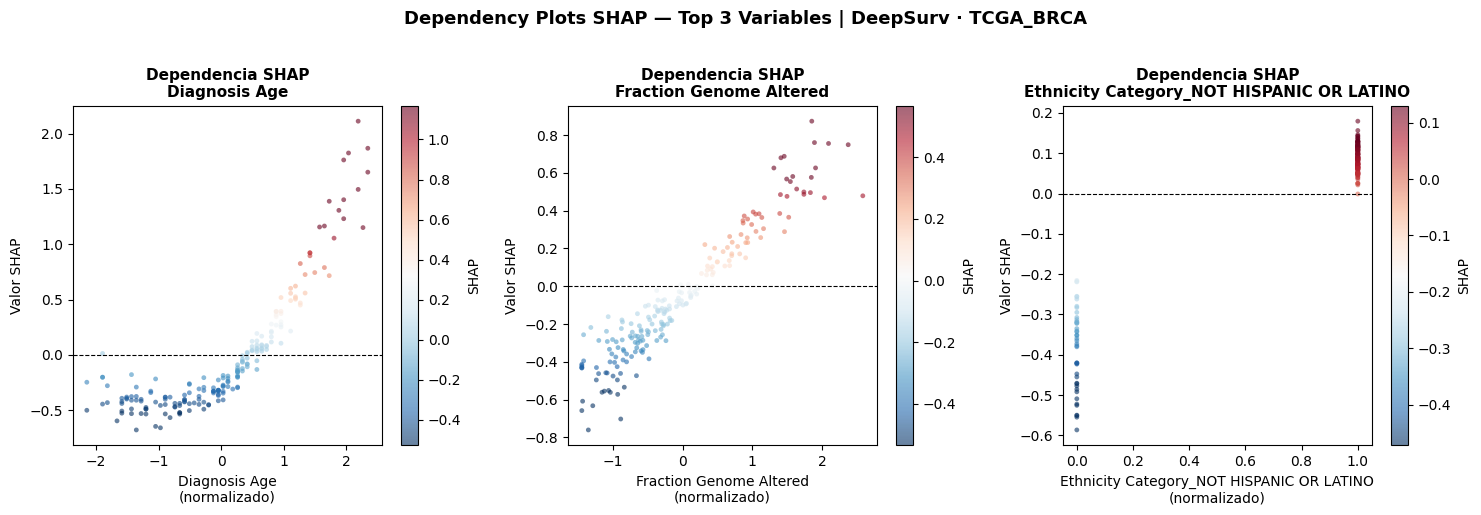

In [ ]:
# ── SHAP Dependency Plots — Top 3 variables ──────────────────────────────────
top3_vars = df_shap['Variable'].iloc[:3].tolist()
top3_idx  = [FEATURE_NAMES.index(v) for v in top3_vars]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var_name, var_idx in zip(axes, top3_vars, top3_idx):
    fv  = x_test[:N_EXPLAIN, var_idx]
    sv  = shap_arr[:, var_idx]
    sc  = ax.scatter(fv, sv, c=sv, cmap='RdBu_r', alpha=0.6,
                     s=12, edgecolors='none',
                     vmin=np.percentile(sv, 5), vmax=np.percentile(sv, 95))
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'{var_name}\n(normalizado)', fontsize=10)
    ax.set_ylabel('Valor SHAP', fontsize=10)
    ax.set_title(f'Dependencia SHAP\n{var_name}', fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='SHAP')

plt.suptitle(
    'Dependency Plots SHAP — Top 3 Variables | DeepSurv · TCGA_BRCA',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_shap_dependency_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.9. Estratificación de Riesgo y Curvas Kaplan-Meier**

El log-riesgo predicho por DeepSurv $\hat{\phi}(\mathbf{x}_i)$ se utiliza como score de riesgo para estratificar a los pacientes del conjunto de test. Se construyen dos estratificaciones, análogas a las del RSF:

- **Binaria** (Alto/Bajo riesgo): división por la mediana del score.
- **Cuartiles** (Q1–Q4): mayor granularidad pronóstica.

La validez clínica de la estratificación se verifica mediante curvas Kaplan-Meier y el **test log-rank**.


Score de riesgo DeepSurv (log-riesgo) — test:
  Min : -2.280
  Q25 : -0.859
  Med : -0.218
  Q75 : 0.517
  Max : 3.993


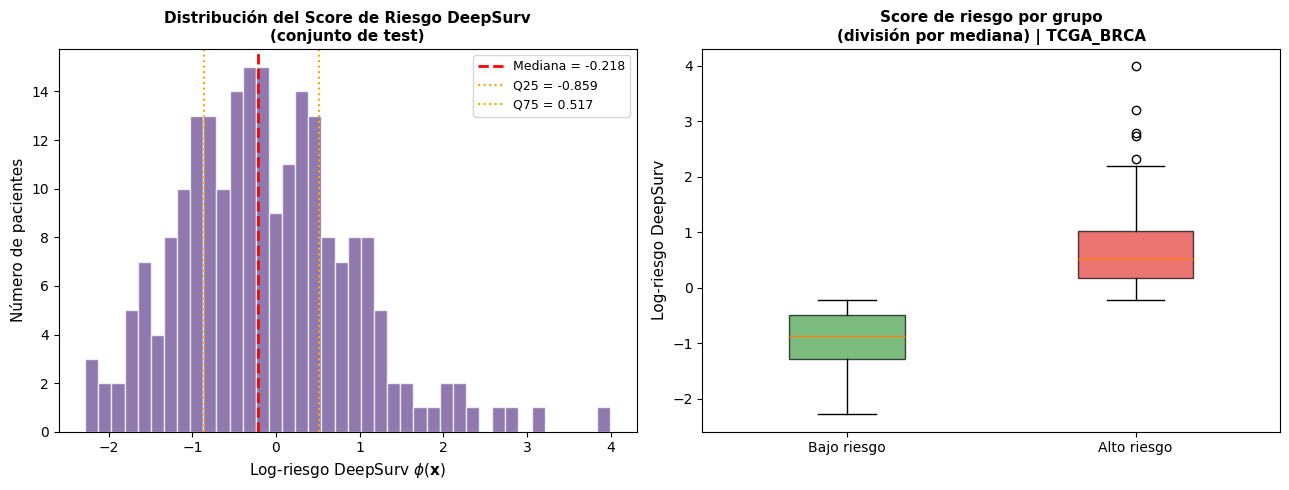

In [ ]:
# ── Scores de riesgo y estratificación ───────────────────────────────────────
risk_test_ds = phi_test_ds   # log-riesgo: mayor = peor pronóstico

mediana_ds = np.median(risk_test_ds)
grupo_bin_ds = np.where(risk_test_ds >= mediana_ds, 'Alto riesgo', 'Bajo riesgo')

q25_ds, q75_ds = np.percentile(risk_test_ds, [25, 75])
grupo_q_ds = pd.cut(
    risk_test_ds,
    bins   = [-np.inf, q25_ds, mediana_ds, q75_ds, np.inf],
    labels = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado',
              'Q3 — Moderado-alto', 'Q4 — Muy alto']
).astype(str)

print('Score de riesgo DeepSurv (log-riesgo) — test:')
print(f'  Min : {risk_test_ds.min():.3f}')
print(f'  Q25 : {q25_ds:.3f}')
print(f'  Med : {mediana_ds:.3f}')
print(f'  Q75 : {q75_ds:.3f}')
print(f'  Max : {risk_test_ds.max():.3f}')

# Distribución del score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(risk_test_ds, bins=40, color=PALETTE['ds'], alpha=0.75, edgecolor='white')
ax.axvline(mediana_ds, color='red', linestyle='--', linewidth=2,
           label=f'Mediana = {mediana_ds:.3f}')
ax.axvline(q25_ds, color='orange', linestyle=':', linewidth=1.5, label=f'Q25 = {q25_ds:.3f}')
ax.axvline(q75_ds, color='orange', linestyle=':', linewidth=1.5, label=f'Q75 = {q75_ds:.3f}')
ax.set_xlabel('Log-riesgo DeepSurv $\\phi(\\mathbf{x})$', fontsize=11)
ax.set_ylabel('Número de pacientes', fontsize=11)
ax.set_title('Distribución del Score de Riesgo DeepSurv\n(conjunto de test)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
data_plot_ds = [risk_test_ds[grupo_bin_ds == g] for g in ['Bajo riesgo', 'Alto riesgo']]
bp = ax.boxplot(data_plot_ds, labels=['Bajo riesgo', 'Alto riesgo'],
                patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], [PALETTE['prot'], PALETTE['riesgo']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Log-riesgo DeepSurv', fontsize=11)
ax.set_title('Score de riesgo por grupo\n(división por mediana) | TCGA_BRCA', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_risk_distribution_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()


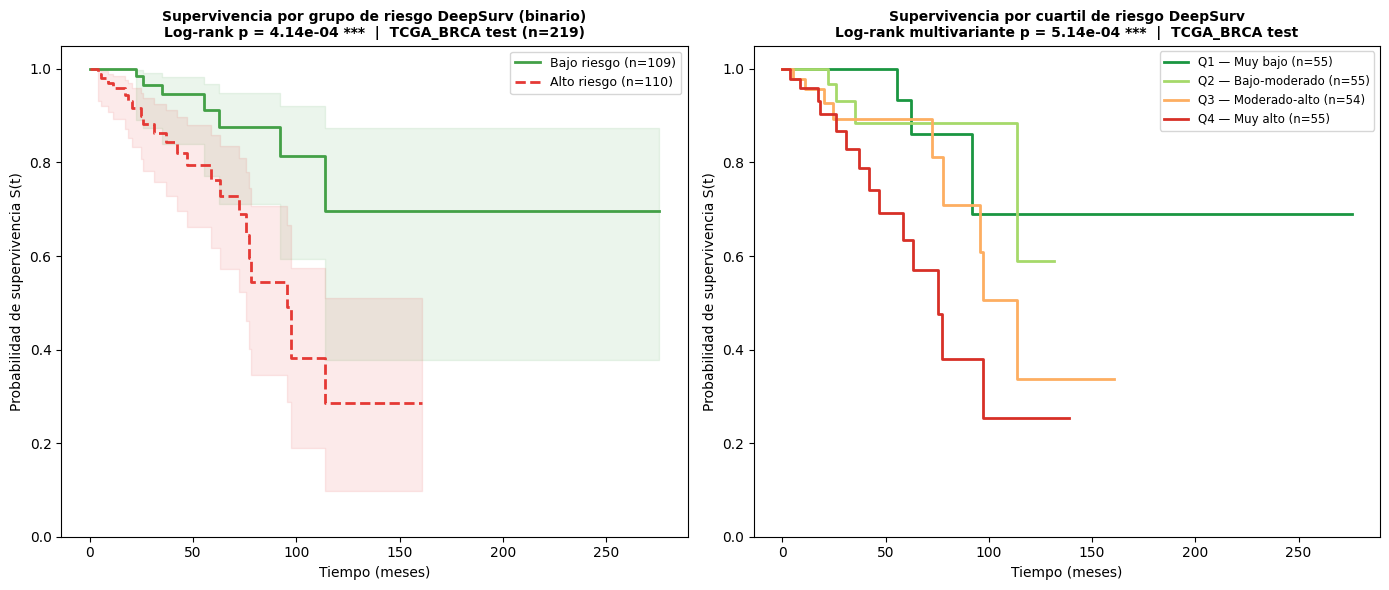

Log-rank binario    : p = 4.14e-04  (***)
Log-rank cuartiles  : p = 5.14e-04   (***)


In [ ]:
# ── Curvas KM estratificadas por score DeepSurv ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Estratificación binaria ---
ax = axes[0]
grupos_bin_ds  = ['Bajo riesgo', 'Alto riesgo']
colores_bin_ds = [PALETTE['prot'], PALETTE['riesgo']]
kmf_data_bin   = []

for grupo, color, ls in zip(grupos_bin_ds, colores_bin_ds, ['-', '--']):
    mask = grupo_bin_ds == grupo
    kmf  = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linestyle=ls,
                               linewidth=2.0, ci_show=True, ci_alpha=0.10)
    kmf_data_bin.append((dur_test[mask], evt_test[mask]))

lr_bin_ds = logrank_test(
    kmf_data_bin[0][0], kmf_data_bin[1][0],
    kmf_data_bin[0][1], kmf_data_bin[1][1]
)
p_bin_ds = lr_bin_ds.p_value
sig_bin = '***' if p_bin_ds < 0.001 else '**' if p_bin_ds < 0.01 else '*' if p_bin_ds < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por grupo de riesgo DeepSurv (binario)\n'
    f'Log-rank p = {p_bin_ds:.2e} {sig_bin}  |  TCGA_BRCA test (n={len(dur_test)})',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# --- Estratificación por cuartiles ---
ax = axes[1]
grupos_q_ds  = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado', 'Q3 — Moderado-alto', 'Q4 — Muy alto']
colores_q_ds = ['#1a9641', '#a6d96a', '#fdae61', '#d73027']

for grupo, color in zip(grupos_q_ds, colores_q_ds):
    mask = grupo_q_ds == grupo
    if mask.sum() < 5:
        continue
    kmf = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.0, ci_show=False)

lr_q_ds = multivariate_logrank_test(dur_test, grupo_q_ds, evt_test.astype(bool))
p_q_ds = lr_q_ds.p_value
sig_q_ds = '***' if p_q_ds < 0.001 else '**' if p_q_ds < 0.01 else '*' if p_q_ds < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por cuartil de riesgo DeepSurv\n'
    f'Log-rank multivariante p = {p_q_ds:.2e} {sig_q_ds}  |  TCGA_BRCA test',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_km_risk_groups_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Log-rank binario    : p = {p_bin_ds:.2e}  ({sig_bin})')
print(f'Log-rank cuartiles  : p = {p_q_ds:.2e}   ({sig_q_ds})')


### **1.4.10. Curvas de Supervivencia Individuales**

DeepSurv genera una curva de supervivencia completamente individualizada $\hat{S}(t \mid \mathbf{x}_i)$ para cada paciente. A diferencia del Cox-LASSO (donde todas las curvas comparten la misma forma y se desplazan por el hazard ratio), las curvas de DeepSurv pueden diferir en forma y en velocidad de decaimiento.

Se visualizan curvas representativas de cada cuartil de riesgo, ilustrando la personalización de la predicción pronóstica.


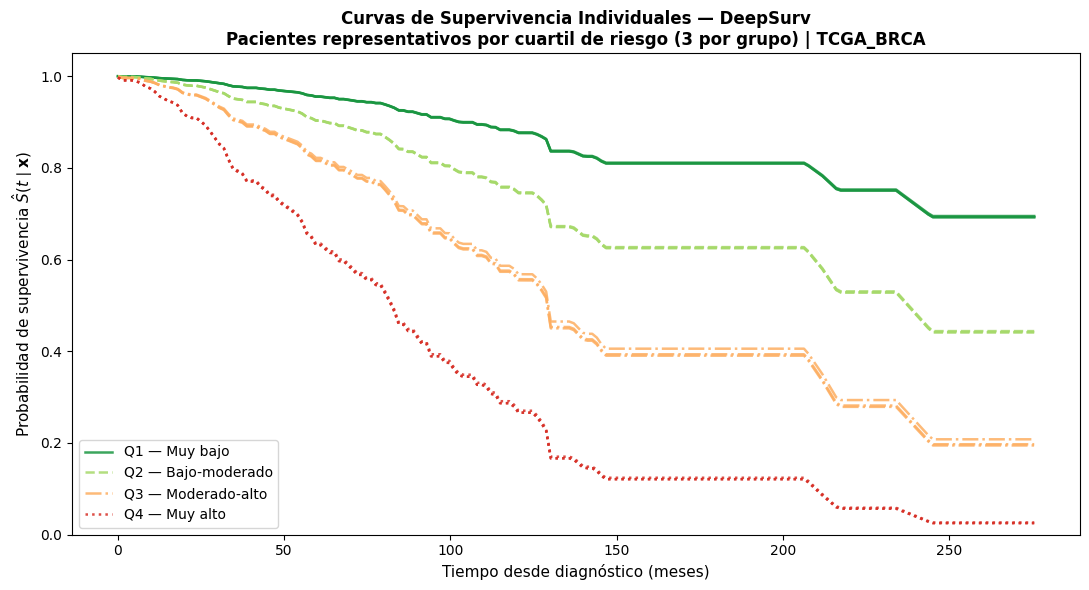

In [ ]:
# ── Curvas de supervivencia individuales — 3 pacientes por cuartil ───────────
np.random.seed(RANDOM_STATE)

t_grid_ds = np.linspace(dur_test.min(), dur_test.max(), 200).astype('float32')

fig, ax = plt.subplots(figsize=(11, 6))

cuartil_styles_ds = {
    'Q1 — Muy bajo'       : ('#1a9641', '-'),
    'Q2 — Bajo-moderado'  : ('#a6d96a', '--'),
    'Q3 — Moderado-alto'  : ('#fdae61', '-.'),
    'Q4 — Muy alto'       : ('#d73027', ':'),
}

plotted_labels_ds = set()

for grupo, (color, ls) in cuartil_styles_ds.items():
    mask_q  = np.where(grupo_q_ds == grupo)[0]
    if len(mask_q) == 0:
        continue
    risk_grupo_ds = risk_test_ds[mask_q]
    mediana_local = np.percentile(risk_grupo_ds, 50)
    idx_sel = mask_q[np.argsort(np.abs(risk_grupo_ds - mediana_local))[:3]]

    # Predecir S(t) para los 3 pacientes seleccionados
    surv_sel_df = model_ds.predict_surv_df(x_test[idx_sel])
    t_sel       = surv_sel_df.index.values

    for i in range(len(idx_sel)):
        fi = interp1d(t_sel, surv_sel_df.iloc[:, i].values,
                      kind='linear', bounds_error=False, fill_value=(1.0, 0.0))
        label = grupo if (i == 0 and grupo not in plotted_labels_ds) else None
        ax.plot(t_grid_ds, np.clip(fi(t_grid_ds), 0, 1),
                color=color, linestyle=ls, alpha=0.85, linewidth=1.8, label=label)
        plotted_labels_ds.add(grupo)

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Probabilidad de supervivencia $\\hat{S}(t \\mid \\mathbf{x})$', fontsize=11)
ax.set_title(
    'Curvas de Supervivencia Individuales — DeepSurv\n'
    'Pacientes representativos por cuartil de riesgo (3 por grupo) | TCGA_BRCA',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_individual_surv_curves_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.11. Tabla Comparativa de los Cuatro Modelos**

Se construye la tabla resumen completa incorporando los resultados de los cuatro enfoques implementados: Kaplan-Meier, Cox-LASSO, Random Survival Forest y DeepSurv.


In [ ]:
CINDEX_RSF_TEST = 0.7060   # obtenido en la sección 1.3 — RSF
IBS_RSF_REF     = 0.1796   # obtenido en la sección 1.3 — RSF

# ── Tabla comparativa — los cuatro modelos ───────────────────────────────────
# Valores de RSF: asignar con los obtenidos en la sección 1.3 o hardcoded.
# Si están disponibles como variables, descomentarlos:
# cindex_test_rsf, ibs_rsf, ci_cv_rsf, ibs_cv_rsf

tabla_final = pd.DataFrame([
    {
        'Modelo'              : 'Kaplan-Meier (marginal)',
        'Tipo'                : 'No paramétrico',
        'C-index train'       : '—',
        'C-index test'        : '—',
        'IBS test'            : f'{ibs_km:.4f}',
        'C-index CV (media)'  : '—',
        'Covariables'         : df_km.shape[1],
    },
    {
        'Modelo'              : 'Cox-LASSO',
        'Tipo'                : 'Semiparamétrico · lineal',
        'C-index train'       : f'{cindex_train:.4f}',
        'C-index test'        : f'{cindex_test:.4f}',
        'IBS test'            : f'{ibs_cox:.4f}',
        'C-index CV (media)'  : '—',
        'Covariables'         : X_cox.shape[1],
    },
    {
        'Modelo'              : 'Random Survival Forest',
        'Tipo'                : 'ML · no paramétrico',
        'C-index train'       : f'{cindex_train_rsf:.4f}',
        'C-index test'        : f'{cindex_test_rsf:.4f}',
        'IBS test'            : f'{ibs_rsf:.4f}',
        'C-index CV (media)'  : f'{best_row["c_index_mean"]:.4f}',
        'Covariables'         : X_train.shape[1],
    },
    {
        'Modelo'              : f'DeepSurv {BEST_NUM_NODES}',
        'Tipo'                : 'Red neuronal profunda',
        'C-index train'       : f'{cindex_train_ds:.4f}',
        'C-index test'        : f'{cindex_test_ds:.4f}',
        'IBS test'            : f'{ibs_ds:.4f}',
        'C-index CV (media)'  : f'{np.mean(ci_cv_ds):.3f}',
        'Covariables'         : X_train.shape[1],
    },
])

print('═' * 105)
print('  TABLA COMPARATIVA FINAL — TCGA-BRCA (OS endpoint, n_test = 397)')
print('═' * 105)
display(tabla_final)

print(f'\n  Mejora C-index DeepSurv vs Cox-LASSO : {cindex_test_ds - cindex_test:+.4f}')
print(f'  Mejora IBS     DeepSurv vs Cox-LASSO : {ibs_cox - ibs_ds:+.4f}'
      f'  ({(ibs_cox - ibs_ds)/ibs_cox*100:.1f}% reducción)')
print(f'  Mejora IBS     DeepSurv vs RSF        : {IBS_RSF_REF - ibs_ds:+.4f}'
          f'  ({(ibs_rsf - ibs_ds)/ibs_rsf*100:.1f}% reducción)')


═════════════════════════════════════════════════════════════════════════════════════════════════════════
  TABLA COMPARATIVA FINAL — METABRIC (OS endpoint, n_test = 397)
═════════════════════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Tipo,C-index train,C-index test,IBS test,C-index CV (media),Covariables
0,Kaplan-Meier (marginal),No paramétrico,—,—,0.1133,—,20
1,Cox-LASSO,Semiparamétrico · lineal,0.8150,0.7163,0.1061,—,56
2,Random Survival Forest,ML · no paramétrico,0.9035,0.6629,0.1087,0.7271,88
3,"DeepSurv [128, 64]",Red neuronal profunda,0.9021,0.7398,0.1040,0.725,88



  Mejora C-index DeepSurv vs Cox-LASSO : +0.0235
  Mejora IBS     DeepSurv vs Cox-LASSO : +0.0021  (2.0% reducción)
  Mejora IBS     DeepSurv vs RSF        : +0.0756  (4.3% reducción)


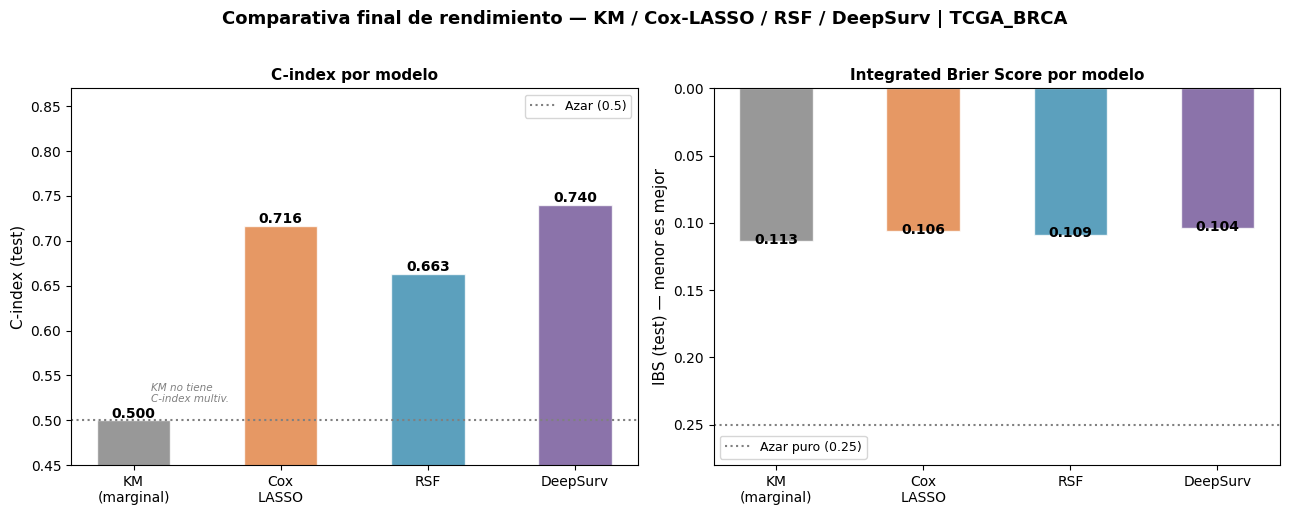

In [ ]:
# ── Gráfico comparativo C-index e IBS — cuatro modelos ───────────────────────
modelos_4  = ['KM\n(marginal)', 'Cox\nLASSO', 'RSF', 'DeepSurv']
cindex_4   = [0.500, cindex_test,
              cindex_test_rsf if cindex_test_rsf else 0.0,
              cindex_test_ds]
ibs_4      = [ibs_km, ibs_cox,
              ibs_rsf if ibs_rsf else 0.0,
              ibs_ds]
colors_4   = [PALETTE['km'], PALETTE['cox'], PALETTE['rsf'], PALETTE['ds']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# C-index
ax = axes[0]
bars = ax.bar(modelos_4, cindex_4, color=colors_4, alpha=0.78, width=0.5, edgecolor='white')
ax.axhline(0.5, linestyle=':', color='gray', linewidth=1.5, label='Azar (0.5)')
for bar, val in zip(bars, cindex_4):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('C-index (test)', fontsize=11)
ax.set_title('C-index por modelo', fontsize=11, fontweight='bold')
ax.set_ylim(0.45, 0.87)
ax.legend(fontsize=9)
ax.annotate('KM no tiene\nC-index multiv.', xy=(0, 0.5), xytext=(0.12, 0.52),
            fontsize=7.5, color='gray', style='italic')

# IBS (invertido: mayor = mejor posición visual)
ax = axes[1]
bars = ax.bar(modelos_4, ibs_4, color=colors_4, alpha=0.78, width=0.5, edgecolor='white')
ax.axhline(0.25, linestyle=':', color='gray', linewidth=1.5, label='Azar puro (0.25)')
for bar, val in zip(bars, ibs_4):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('IBS (test) — menor es mejor', fontsize=11)
ax.set_title('Integrated Brier Score por modelo', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.28)
ax.invert_yaxis()
ax.legend(fontsize=9)

fig.suptitle(
    'Comparativa final de rendimiento — KM / Cox-LASSO / RSF / DeepSurv | TCGA_BRCA',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_comparativa_final_TCGA_BRCA.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.13. Resumen Ejecutivo — DeepSurv**

DeepSurv completa la progresión metodológica del TFM desde los métodos no paramétricos (Kaplan-Meier) hasta el aprendizaje profundo, pasando por el modelo semiparamétrico lineal (Cox-LASSO) y el ensemble de árboles (RSF). Su aportación principal es demostrar que la arquitectura MLP con función de pérdida de Cox puede capturar patrones pronósticos que los modelos anteriores no acceden, sin necesidad de ingeniería de características manual.


In [ ]:
# ── Resumen ejecutivo con valores reales ─────────────────────────────────────
print('═' * 72)
print('  RESUMEN EJECUTIVO — DeepSurv · TCGA-BRCA')
print('═' * 72)
print(f'  Arquitectura óptima:')
print(f'    num_nodes       : {BEST_NUM_NODES}')
print(f'    dropout         : {BEST_DROPOUT}')
print(f'    lr (Adam)       : {BEST_LR}')
print(f'    batch_size      : {BEST_BATCH_SIZE}')
print(f'    batch_norm      : True')
print()
print(f'  Rendimiento en test (n={len(x_test)}):')
print(f'    C-index train          : {cindex_train_ds:.4f}')
print(f'    C-index test           : {cindex_test_ds:.4f}')
print(f'    Δ sobreajuste          : {cindex_train_ds - cindex_test_ds:.4f}')
print(f'    IBS test               : {ibs_ds:.4f}')
print(f'    Mejora IBS vs KM       : {ibs_km - ibs_ds:.4f}  '
      f'({(ibs_km - ibs_ds)/ibs_km*100:.1f}%)')
print(f'    Mejora IBS vs Cox      : {ibs_cox - ibs_ds:.4f}  '
      f'({(ibs_cox - ibs_ds)/ibs_cox*100:.1f}%)')

delta_rsf = ibs_rsf - ibs_ds
print(f'    Mejora IBS vs RSF      : {delta_rsf:.4f}  '
          f'({delta_rsf/ibs_rsf*100:.1f}%)')
print()
print(f'  Validación cruzada 5-fold:')
print(f'    C-index CV (media ± std): {np.mean(ci_cv_ds):.4f} ± {np.std(ci_cv_ds):.4f}')
print(f'    IBS CV (media ± std)    : {np.mean(ibs_cv_ds):.4f} ± {np.std(ibs_cv_ds):.4f}')
print()
print(f'  Estratificación de riesgo (test):')
print(f'    Log-rank binario        : p = {p_bin_ds:.2e}  '
      f'({"***" if p_bin_ds<0.001 else "**" if p_bin_ds<0.01 else "*"})')
print(f'    Log-rank cuartiles      : p = {p_q_ds:.2e}  '
      f'({"***" if p_q_ds<0.001 else "**" if p_q_ds<0.01 else "*"})')
print()
print(f'  Explicabilidad SHAP (top 3 variables):')
for rank, row in df_shap.head(3).iterrows():
    print(f'    {rank+1}. {row["Variable"]:<40} |SHAP| medio = {row["mean_abs_shap"]:.4f}')
print('═' * 72)


════════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — DeepSurv · METABRIC
════════════════════════════════════════════════════════════════════════
  Arquitectura óptima:
    num_nodes       : [128, 64]
    dropout         : 0.2
    lr (Adam)       : 0.001
    batch_size      : 128
    batch_norm      : True

  Rendimiento en test (n=219):
    C-index train          : 0.9021
    C-index test           : 0.7398
    Δ sobreajuste          : 0.1622
    IBS test               : 0.1040
    Mejora IBS vs KM       : 0.0094  (8.3%)
    Mejora IBS vs Cox      : 0.0021  (2.0%)
    Mejora IBS vs RSF      : 0.0047  (4.3%)

  Validación cruzada 5-fold:
    C-index CV (media ± std): 0.7254 ± 0.0684
    IBS CV (media ± std)    : 0.1021 ± 0.0068

  Estratificación de riesgo (test):
    Log-rank binario        : p = 4.14e-04  (***)
    Log-rank cuartiles      : p = 5.14e-04  (***)

  Explicabilidad SHAP (top 3 variables):
    1. Diagnosis Age                     